# Pairs trading on the day lake — VI. A statistical-arbitrage desk in miniature

## `pairs_trading_17_desk_alphas_day_lake.ipynb`

Notebook 12 traded one weak daily signal — five-session reversal — against a PCA factor model and
found a gross edge that clears its measured cost before 2016 and dies after. This notebook asks
whether **combining several weak, cheap, pre-registered alphas**, neutralizing the combination
against a richer risk model, and controlling turnover explicitly, can lift the same cross-section
above zero net of measured cost in the period where the single-signal book failed — and whether the
result is a fair second running example for notebook 14's tradeable-edge scorecard.

Everything below was fixed before any cell in this notebook ran, in
`notebooks/build/nb17_desk_preregistration.md`, reproduced verbatim in §0.1. No alpha, window,
threshold, universe cap, blend or decision rule was changed after the first execution; every place
this build could not do something exactly as written is logged in §10, Deviations.

**Caching.** Three passes are cached under `notebooks/cache/` (gitignored), all under the `desk_`
prefix this notebook alone is allowed to write: the open/high/low panel joined from the lake's
market layout (`desk_ohlc.parquet`), the risk-model + alpha panel built by the daily loop
(`desk_alpha_panel.parquet`), and the daily neutralization loadings the portfolio pass reuses
(`desk_loadings.pkl`). Every other cache in this repository is read-only from this notebook's point
of view, including notebook 12's `xs_costs.parquet` (stock transaction costs) and notebook 15's
sector-ETF machinery, which is imported rather than recomputed.

### 0.1 The pre-registration, verbatim

# Pre-registration: notebook 17, a statistical-arbitrage desk in miniature

Written 2026-09-28, before any of the code below exists or any number has been seen. Everything in
this file is fixed. Anything the notebook does differently must be listed in a "Deviations" section
at its end, with the reason.

## Question

Does combining several weak daily alphas, neutralizing them against a risk model, and controlling
turnover lift the day-lake cross-section above zero **net of measured costs** after 2015, where
notebook 12's single reversal signal died? Secondary: does the resulting book qualify as a
like-for-like second running example for notebook 14?

## Data and universe

- Day lake, market layout (`all_adjusted`), split-adjusted open/high/low/close and volume, dividends
  accrued from the factor steps as in notebook 09. The lakes are read-only; nb20 writes only caches
  prefixed `desk_` under `notebooks/cache/`.
- Point-in-time universe: notebook 09's liquidity rules, capped at the 500 most traded eligible
  names, rebuilt monthly (exactly notebook 12's `universe_at`).
- Sessions 2004-01-02 to 2025-08-13. The first two years are warm-up only.

## Periods

| Period | Span | Use |
|---|---|---|
| Development | 2006-01-04 to 2015-12-31 | every fit, every selection, every look |
| Test | 2016-01-04 to 2022-12-30 | reported after development is frozen |
| Hold-out | 2023-01-03 to 2025-08-13 | notebook 11's hold-out window; computed once, at the end |

## Target

Forward return over **h = 5** sessions (primary), hedged against the risk model with **no in-sample
intercept** (the notebook 12 fix). h = 1 and h = 21 are reported for every alpha but nothing is
selected on them. Timing is notebook 12's: signals use data through the close of session t and the
position is held from that close.

## The alpha list (fixed)

Each alpha is cross-sectionally standardized every day within the universe (median and MAD,
winsorized at ±3), then multiplied by its pre-registered sign. The univariate IC test uses that sign;
the blend is free to disagree, and where it does the notebook says so.

| # | Name | Definition (data through session t) | Sign | Source |
|---|---|---|---|---|
| 1 | `rev1` | residual return over session t | − | Lehmann 1990; Lo & MacKinlay 1990 |
| 2 | `rev5` | residual return over sessions t−4..t (notebook 12's signal) | − | notebook 12 |
| 3 | `ind_rev5` | 5-session return minus the sector-ETF-implied return (notebook 15's ETF residual) | − | notebook 15; Avellaneda & Lee 2010 |
| 4 | `sscore` | notebook 15's OU s-score on the ETF residual, 60-session window | − | Avellaneda & Lee 2010 |
| 5 | `mom1m` | return over sessions t−20..t | − | Jegadeesh 1990 |
| 6 | `mom12_1` | return over sessions t−251..t−21 | + | Jegadeesh & Titman 1993 |
| 7 | `vol_abn` | log(volume_t / median volume over t−19..t) | + | Gervais, Kaniel & Mingelgrin 2001 |
| 8 | `ovn21` | sum over t−20..t of log(open_s / close_{s−1}) | + | Lou, Polk & Skouras 2019 |
| 9 | `pvol21` | mean over t−20..t of log(high_s / low_s) (Parkinson range) | − | Ang, Hodrick, Xing & Zhang 2006 |
| 10 | `high52` | close_t / max(high over t−251..t) | + | George & Hwang 2004 |
| 11 | `max21` | max single-session return over t−20..t | − | Bali, Cakici & Whitelaw 2011 |

Residual returns in 1–2 are relative to the risk model below. Nothing is added to this list after
the first run. An alpha that cannot be computed as written is dropped and the drop is logged.

## Risk model and neutralization

Notebook 12's monthly PCA loadings (same k), plus the nine sector ETFs of notebook 15 as explicit
columns, plus one style column, log dollar volume (size). Positions are projected orthogonal to all
of these and made dollar-neutral with notebook 12's `neutralize`. Momentum is **not** neutralized,
because it is an alpha under test; its factor exposure is reported instead.

## Blends (both fixed)

1. **Equal-weight**: the mean of the eleven signed z-scores. The no-fit baseline.
2. **Ridge**: forward 5-session hedged return regressed on the eleven z-scores, fit on the trailing
   36 months, refit monthly, walk-forward. The ridge penalty is chosen by leave-one-year-out
   cross-validation inside the training window only, from the grid {0.1, 1, 10, 100} in units of
   the design's mean diagonal.

## Turnover control

Target weights come from the blend. Held weights move a fraction φ of the gap to the target each
session (Gârleanu & Pedersen 2013 partial adjustment). **φ = 0.25 is primary.** φ ∈ {1, 0.5, 0.1}
are reported as a sensitivity and nothing is selected on them.

## Costs and metrics

- Costs: notebook 14 §9's measured per-(ticker, year) costs, with flat 5 bps a leg-side as the
  comparison basis and 50 bp/yr borrow on shorts, exactly as notebook 11 charges.
- Per alpha, per period: Pearson IC on the hedged target with the standard error from non-overlapping
  probe days (notebook 12's estimator), the pairwise-complete day count, and the Benjamini–Hochberg
  verdict at q = 0.10 across the eleven alphas in development.
- Per book (two blends × primary φ): gross and net Sharpe with standard error √(252 / sessions),
  turnover per session, break-even cost in bps, exposure to each neutralized and non-neutralized
  factor, and the five tradeable-edge clauses of notebook 14 §9.
- Placebo: the same pipeline with each alpha's values permuted across names within each session,
  40 draws; the ridge blend's net Sharpe is reported as a percentile of that null.

## Decision rules, fixed now

- The daily desk **works** if the ridge book's net-of-measured-cost Sharpe on the test period is
  positive with t > 2 and the hold-out Sharpe has the same sign. Otherwise it **does not**, and the
  notebook says the daily-bar desk on liquid US names is out of reach with these alphas.
- It becomes a candidate second example for notebook 14 only if it is like-for-like with notebook
  11's book: same lake, full span, net of measured costs, and a Sharpe above 0.49 by more than the
  combined standard error. This is reported, not decided, in the notebook.
- No parameter, window, threshold, universe cap or alpha definition changes after the first
  development-period run. Sensitivities listed above are reported in full, never chosen from.

## Numbering

The notebook is a day-lake study and belongs with 08–16, so it is notebook 17; the minute-lake
notebooks moved from 17–19 to 18–20 on 2026-09-28 (`renumber.py`), before it was built.

## 1. Setup and data

The day-lake constants are notebook 12's (`build_cross_sectional_notebook.py`, its constants block
and universe/PCA helpers, copied verbatim below), extended with notebook 11/14's cost and borrow
conventions and this notebook's own period boundaries. `ANN`, `BORROW_BPS` and the hold-out split
are notebook 14's.

In [1]:
from pathlib import Path
import os, re, sys, time, pickle, warnings

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

import pairs
from pairs import load_daily_bars, liquidity_screen, benjamini_hochberg_fdr
from pairs.strategies.avellaneda_lee import assign_sector_etf, etf_residuals, ou_fit, s_score

LAKE        = Path(os.environ.get("DAY_LAKE", Path.home() / "local/parquet_lake/day_adj"))
MARKET_ROOT = LAKE / "all_adjusted"
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)

START, END   = "2004-01-01", "2025-08-13"
TRADE_START  = "2006-01-01"
DEV_END      = pd.Timestamp("2015-12-31")
TEST_START   = pd.Timestamp("2016-01-01")
TEST_END     = pd.Timestamp("2022-12-31")
HOLD_START   = pd.Timestamp("2023-01-01")

MIN_PRICE, MIN_DV, MIN_VOL, MAX_ABS_RET = 5.0, 20e6, 0.15, 1.0
UNIV_N, FORM_DAYS, N_FACTORS, REG_DAYS = 500, 252, 15, 60
REBUILD_GAP = 25                         # sessions between universe/PCA/sector-assignment rebuilds
CAP, COST_BPS, BORROW_BPS, ANN = 1_000_000.0, 5.0, 50.0, 252
PHI_PRIMARY = 0.25
PHIS = [0.25, 1.0, 0.5, 0.1]              # primary first, then the sensitivity grid
RIDGE_TRAIL_MONTHS = 36
RIDGE_GRID = [0.1, 1.0, 10.0, 100.0]

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
rng = np.random.default_rng(0)
sharpe = lambda x: x.mean() / x.std(ddof=0) * np.sqrt(ANN) if x.std(ddof=0) > 0 else np.nan
DEVIATIONS = []
print("pairs", pairs.__version__)

pairs 0.1.0


### 1.1 Bars, dividends, sessions

Notebook 12's cached total-return day-lake frame, already on disk from earlier notebooks in this
repository (read-only from here): total returns with the dividend recovered from the adjustment
factors and credited on the ex-date, winsorized at ±100% a day, exchange test symbols dropped.

In [2]:
f_bars = CACHE / "day_market_bars.parquet"
if not f_bars.exists():
    load_daily_bars(None, START, END, MARKET_ROOT, with_dividends=True).to_parquet(f_bars)
bars = pd.read_parquet(f_bars)

px  = bars["close"].unstack("ticker")
div = bars["dividend"].unstack("ticker").reindex_like(px).fillna(0.0)
vol_sh = bars["volume"].unstack("ticker").reindex_like(px)
dv     = bars["dollar_volume"].unstack("ticker").reindex_like(px)
ret = ((px + div) / px.shift(1) - 1.0).clip(-1.0, 1.0)
TESTS = sorted(t for t in px.columns if re.fullmatch(r"Z[A-Z]ZZT", str(t)))
ret = ret.drop(columns=TESTS, errors="ignore")
sessions = ret.index
print(f"{ret.shape[1]:,} tickers x {ret.shape[0]:,} sessions, {sessions[0].date()} -> {sessions[-1].date()}")
print(f"exchange test symbols dropped: {len(TESTS)}")

# the nine classic Select Sector SPDRs -- "the nine sector ETFs of notebook 15" the pre-registration
# names; notebook 15's own candidate list also screens seven further industry ETFs (IYR, SMH, OIH,
# RTH, IBB, IYT, KRE) that are not part of the nine and are not used here.
ETF9 = ["XLB", "XLE", "XLF", "XLI", "XLK", "XLP", "XLU", "XLV", "XLY"]
rows = []
for t in ETF9:
    s = ret[t].dropna()
    pos = sessions.get_indexer(s.index)
    gaps = np.diff(pos) if len(pos) > 1 else np.array([0])
    rows.append({"etf": t, "first": s.index.min().date(), "last": s.index.max().date(),
                 "max_gap_sessions": int(gaps.max()), "n_obs": len(s)})
etf_coverage = pd.DataFrame(rows).set_index("etf")
display(etf_coverage)
BAD9 = etf_coverage.index[(etf_coverage["max_gap_sessions"] > 5)
                          | (pd.to_datetime(etf_coverage["last"]) < pd.Timestamp("2025-01-01"))].tolist()
print(f"dropped from the nine for discontinuity (notebook 15's screen, applied for completeness): {BAD9}")
ETF9 = [t for t in ETF9 if t not in BAD9]
assert "SPY" in ret.columns
etf_ret = ret[ETF9]
print(f"risk-model sector ETFs ({len(ETF9)}): {ETF9}")

33,303 tickers x 5,438 sessions, 2004-01-02 -> 2025-08-13
exchange test symbols dropped: 13


,first,last,max_gap_sessions,n_obs
etf,,,,
XLB,2004-01-05,2025-08-13,1,5437
XLE,2004-01-05,2025-08-13,1,5437
XLF,2004-01-05,2025-08-13,1,5437
XLI,2004-01-05,2025-08-13,1,5437
XLK,2004-01-05,2025-08-13,1,5437
XLP,2004-01-05,2025-08-13,1,5437
XLU,2004-01-05,2025-08-13,1,5437
XLV,2004-01-05,2025-08-13,1,5437
XLY,2004-01-05,2025-08-13,1,5437


dropped from the nine for discontinuity (notebook 15's screen, applied for completeness): []
risk-model sector ETFs (9): ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']


### 1.2 Universe and the point-in-time screen

Notebook 09's liquidity rules, capped at the 500 most traded eligible names, rebuilt every
25 sessions (about monthly) — exactly notebook 12's `universe_at`, with the nine
sector ETFs and SPY excluded from ever being *selected into* the equity universe, since they serve
as risk-model factors here (notebook 15's convention).

In [3]:
def universe_at(end, n=UNIV_N):
    start = end - pd.DateOffset(days=int(FORM_DAYS * 1.6))
    lvl = bars.index.get_level_values("datetime")
    w = bars[(lvl > start) & (lvl <= end)]
    st = liquidity_screen(w, min_price=MIN_PRICE, min_dollar_volume=MIN_DV, min_ann_vol=MIN_VOL,
                          max_abs_return=MAX_ABS_RET, exclude=TESTS, top_n=n)
    names = list(st[st["eligible"]].index)
    return [t for t in names if t not in ETF9 and t != "SPY"]

def eigenportfolios(R, k=N_FACTORS):
    # verbatim from notebook 12 (build_cross_sectional_notebook.py section 2)
    sd = R.std(axis=0); ok = sd > 1e-12
    R, sd = R.loc[:, ok], sd[ok]
    C = np.nan_to_num(np.corrcoef(R.to_numpy(), rowvar=False), nan=0.0)
    vals, vecs = np.linalg.eigh(C)
    idx = np.argsort(vals)[::-1][:k]
    Q = vecs[:, idx] / sd.to_numpy()[:, None]
    Q = Q / np.abs(Q).sum(axis=0, keepdims=True)
    return pd.DataFrame(Q, index=R.columns, columns=[f"f{i}" for i in range(len(idx))]), vals[idx] / vals.sum()

def neutralize(w, B):
    # project orthogonal to [loadings, 1] JOINTLY, then unit-scale. Projecting against B alone and
    # then demeaning (notebook 12's original two-step form) re-injects exposure -mean(w) * colsum(B)
    # into every factor whose loadings do not sum to zero -- confirmed skeptic finding S2. Appending
    # a constant column to B and solving the joint least-squares projection removes the dollar
    # exposure and the factor exposures in one step, with no re-injected tilt.
    B1 = np.column_stack([B, np.ones(B.shape[0])])
    BtB = B1.T @ B1 + 1e-8 * np.eye(B1.shape[1])
    w = w - B1 @ np.linalg.solve(BtB, B1.T @ w)
    g = np.abs(w).sum()
    return w / g if g > 1e-12 else w

def robust_z(x):
    # median/MAD z-score, winsorized at +/-3; NaN input stays NaN
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale < 1e-9:
        return np.full_like(x, np.nan)
    return np.clip((x - med) / scale, -3.0, 3.0)

sample_univ = universe_at(pd.Timestamp("2015-06-30"))
print(f"sample universe (2015-06-30): {len(sample_univ)} names")

sample universe (2015-06-30): 498 names


### 1.3 The open/high/low cache

The cached bars carry close, raw close, volume, dollar volume and dividends only (notebook 09's
join); three alphas (`ovn21`, `pvol21`, `high52`) need the open, high and low the day lake's market
layout carries under `open_split`/`high_split`/`low_split`. The whole lake's split-adjusted OHLC
columns are read once with pyarrow (no per-year loop is needed: pruning to four columns makes a
full-lake read fast), then joined to the cached bars on `(ticker, datetime, id)` so ticker reuse
resolves exactly as the cached frame already resolved it, and cached as `desk_ohlc.parquet`. As a
join sanity check, the lake's own `close_split` is compared against the cached `close` wherever both
exist — they are the same series (`close` is loaded with `price="split"`, notebook 09) and should
agree up to float noise.

In [4]:
f_ohlc = CACHE / "desk_ohlc.parquet"
if f_ohlc.exists():
    ohlc = pd.read_parquet(f_ohlc)
else:
    import pyarrow.dataset as ds
    t0 = time.time()
    bars_flat = bars.reset_index()[["ticker", "datetime", "id", "close"]]
    need_ids = set(bars_flat["id"].unique())
    dataset = ds.dataset(MARKET_ROOT, format="parquet")
    tbl = dataset.to_table(
        columns=["datetime", "ticker", "id", "open_split", "high_split", "low_split", "close_split"],
        filter=ds.field("id").isin(need_ids))
    raw = tbl.to_pandas()
    raw["ticker"] = raw["ticker"].astype(str).str.upper()
    raw["datetime"] = (raw["datetime"].dt.tz_localize("UTC").dt.tz_convert("US/Eastern")
                        .dt.tz_localize(None).dt.normalize())
    merged = bars_flat.merge(raw, on=["ticker", "datetime", "id"], how="inner")
    merged = merged.drop_duplicates(subset=["ticker", "datetime"])
    diff = (merged["close_split"] - merged["close"]).abs()
    print(f"OHLC join sanity check: {len(merged):,} of {len(bars_flat):,} cached rows matched an "
          f"(ticker, datetime, id) triple in the lake; close_split vs cached close: max abs diff "
          f"{diff.max():.2f}, {100 * (diff > 1e-6).mean():.4f}% of rows differ by more than 1e-6")
    ohlc = merged.set_index(["ticker", "datetime"])[["open_split", "high_split", "low_split"]]
    ohlc.columns = ["open", "high", "low"]
    ohlc.to_parquet(f_ohlc)
    print(f"desk_ohlc.parquet built in {time.time() - t0:.0f}s, {len(ohlc):,} rows")

open_p = ohlc["open"].unstack("ticker").reindex(index=sessions, columns=ret.columns)
high_p = ohlc["high"].unstack("ticker").reindex(index=sessions, columns=ret.columns)
low_p  = ohlc["low"].unstack("ticker").reindex(index=sessions, columns=ret.columns)
print(f"OHLC panel: {open_p.shape[1]:,} tickers x {open_p.shape[0]:,} sessions, "
      f"{100 * open_p.notna().to_numpy().mean():.1f}% non-null open cells")

OHLC panel: 33,303 tickers x 5,438 sessions, 24.2% non-null open cells


## 2. Risk model, and the seven alphas that need no risk model

Two different residualizations are used in this notebook and it matters which alpha uses which:

* Alphas 1-2 (`rev1`, `rev5`) are residuals against the **combined risk model** built below: notebook
  12's monthly PCA (k=15), plus the nine sector ETFs as explicit factor-return columns, fit jointly
  by OLS with an intercept over the trailing 60 sessions. This is also the model the hedged forward
  target `fwd{h}` is built from, with **no in-sample intercept** carried into the forward projection
  (notebook 12's fix, §3.1 of that notebook): `fwd{h} = stock forward return - beta_hat . factor
  forward returns`, never `- (alpha_hat + beta_hat . factor forward returns)`.
* Alphas 3-4 (`ind_rev5`, `sscore`) use a *different*, narrower residual: each name's return against
  its own single **assigned** sector ETF (notebook 15's `assign_sector_etf` / `etf_residuals` /
  `ou_fit` / `s_score`, reused verbatim, not reimplemented).
* A size style factor (log dollar volume, trailing 21 sessions, robust z-scored) is added to the
  combined model's loadings for **neutralization only** (portfolio construction, §6): dollar volume
  has no return series of its own, so it cannot enter the forward-return hedge, only the projection
  that removes it from the traded book's exposure.

Alphas 5-11 need none of this: they are point-in-time functions of price, volume and OHLC history
alone, and are computed once, vectorized, over the full ticker-by-session panel below, rather than
inside the per-session loop.

In [5]:
logret = np.log1p(ret)
mom1m   = np.expm1(logret.rolling(21).sum())                                  # sessions t-20..t
mom12_1 = np.expm1(logret.rolling(231).sum().shift(21))                       # sessions t-251..t-21
vol_abn = np.log(vol_sh / vol_sh.rolling(20).median())                        # t-19..t inclusive
ovn21   = np.log(open_p / px.shift(1)).rolling(21).sum()                      # sum_t-20..t log(open/close_-1)
pvol21  = np.log(high_p / low_p).rolling(21).mean()                           # mean_t-20..t log(high/low)
high52  = px / high_p.rolling(252).max()                                      # t-251..t inclusive
max21   = ret.rolling(21).max()                                               # t-20..t inclusive

RAW_PANELS = {"mom1m": mom1m, "mom12_1": mom12_1, "vol_abn": vol_abn, "ovn21": ovn21,
              "pvol21": pvol21, "high52": high52, "max21": max21}
for name, panel in RAW_PANELS.items():
    print(f"{name:10s} coverage over all tickers/sessions: {100*panel.notna().to_numpy().mean():.1f}%")

mom1m      coverage over all tickers/sessions: 21.2%
mom12_1    coverage over all tickers/sessions: 17.1%


vol_abn    coverage over all tickers/sessions: 21.3%
ovn21      coverage over all tickers/sessions: 21.2%


pvol21     coverage over all tickers/sessions: 21.3%
high52     coverage over all tickers/sessions: 17.0%


max21      coverage over all tickers/sessions: 21.2%


## 3. The eleven alphas

Each is defined exactly as the pre-registration's table (§0.1), computed from data through the close
of session `t` only. The main loop below rebuilds the universe, the PCA eigenportfolios and the
sector assignment every 25 sessions, then every session: fits the combined risk
model over the trailing 60 sessions, fits the single-ETF residual for `ind_rev5`/`sscore`, reads off
the seven vectorized alphas for the day's universe, cross-sectionally standardizes all eleven
(median/MAD, winsorized at +/-3) over the same universe, multiplies each by its pre-registered sign,
and builds the hedged forward targets `fwd1`, `fwd5`, `fwd21`. Timing has no look-ahead by
construction: the risk-model window and every alpha use rows up to and including `i` (session `t`);
the forward target starts at `i+1` (session `t+1`).

In [6]:
SIGN = {"rev1": -1, "rev5": -1, "ind_rev5": -1, "sscore": -1, "mom1m": -1, "mom12_1": 1,
        "vol_abn": 1, "ovn21": 1, "pvol21": -1, "high52": 1, "max21": -1}
ALPHAS = list(SIGN)
print("alpha order and sign:", SIGN)

alpha order and sign: {'rev1': -1, 'rev5': -1, 'ind_rev5': -1, 'sscore': -1, 'mom1m': -1, 'mom12_1': 1, 'vol_abn': 1, 'ovn21': 1, 'pvol21': -1, 'high52': 1, 'max21': -1}


In [7]:
f_panel = CACHE / "desk_alpha_panel.parquet"
f_load  = CACHE / "desk_loadings.pkl"

trade_sessions = sessions[(sessions >= TRADE_START) & (sessions <= END)]
MIN_ETF_NAMES = 10
N_SKIPPED = 0

if f_panel.exists() and f_load.exists():
    panel = pd.read_parquet(f_panel)
    with open(f_load, "rb") as fh:
        LOADINGS = pickle.load(fh)
    print(f"loaded cached panel ({len(panel):,} rows) and {len(LOADINGS):,} days of loadings")
else:
    t0 = time.time()
    last_rebuild, univ, assign_df, Q = None, [], None, None
    rows, LOADINGS = [], {}

    for d in trade_sessions:
        i = sessions.get_loc(d)
        if i < FORM_DAYS + REG_DAYS + 2 or i + 1 + 21 >= len(sessions):
            continue
        if last_rebuild is None or (d - last_rebuild).days > REBUILD_GAP:
            hist_all = ret.iloc[i - FORM_DAYS + 1:i + 1]
            cand = universe_at(d)
            hist = hist_all.reindex(columns=cand).dropna(axis=1)
            if hist.shape[1] < 50:
                continue
            Q, _ = eigenportfolios(hist)
            univ = list(Q.index)
            assign_df = assign_sector_etf(hist, etf_ret.iloc[i - FORM_DAYS + 1:i + 1], min_obs=200)
            last_rebuild = d

        win = ret.iloc[i - REG_DAYS + 1:i + 1].reindex(columns=univ).dropna(axis=1)
        if win.shape[1] < 50:
            N_SKIPPED += 1
            continue
        cols = win.columns
        n = len(cols)

        # ---- combined risk model: PCA(15) + 9 sector ETFs, joint OLS with intercept ----
        Qw = Q.reindex(cols).to_numpy()
        F_pca = win.to_numpy() @ Qw
        F_etf = etf_ret.loc[win.index, ETF9].to_numpy()
        Fm = np.column_stack([np.ones(len(win)), F_pca, F_etf])
        beta_full, *_ = np.linalg.lstsq(Fm, win.to_numpy(), rcond=None)
        resid_full = win.to_numpy() - Fm @ beta_full
        r2_joint = 1.0 - resid_full.var(0) / np.maximum(win.to_numpy().var(0), 1e-18)

        rev1_raw = pd.Series(resid_full[-1], index=cols)
        rev5_raw = pd.Series(resid_full[-5:].sum(0), index=cols)

        # ---- single assigned-ETF residual (notebook 15's construction) ----
        etf_of_all = assign_df["etf"].reindex(cols)
        ok_etf = (etf_of_all.notna() & etf_of_all.isin(ETF9)).to_numpy()
        cols_etf = cols[ok_etf]
        ind_rev5_raw = pd.Series(np.nan, index=cols)
        sscore_raw = pd.Series(np.nan, index=cols)
        if len(cols_etf) >= MIN_ETF_NAMES:
            win_etf = win[cols_etf]
            etf_series = etf_ret.loc[win.index, etf_of_all[cols_etf].tolist()]
            etf_series.columns = cols_etf
            fit_single = etf_residuals(win_etf.to_numpy(), etf_series.to_numpy(), weights=None)
            ou_single = ou_fit(fit_single["resid"])
            s_single = s_score(ou_single, center=True)
            ind_rev5_raw.loc[cols_etf] = fit_single["resid"][-5:].sum(0)
            sscore_raw.loc[cols_etf] = s_single

        # ---- size style column, for neutralization only ----
        dv_mean = dv.iloc[i - 20:i + 1].reindex(columns=cols).mean(axis=0)
        size_z = robust_z(np.log(dv_mean.to_numpy()))

        # ---- alphas 5-11, read off the vectorized panels ----
        raw = {"rev1": rev1_raw.to_numpy(), "rev5": rev5_raw.to_numpy(),
               "ind_rev5": ind_rev5_raw.to_numpy(), "sscore": sscore_raw.to_numpy()}
        for name, panelv in RAW_PANELS.items():
            raw[name] = panelv.loc[d, cols].to_numpy()

        z = {a: robust_z(raw[a]) for a in ALPHAS}
        signed = {a: SIGN[a] * z[a] for a in ALPHAS}

        # ---- hedged forward targets, no in-sample intercept, h = 1, 5, 21 ----
        fwd_row = {}
        for h in (1, 5, 21):
            fwd_stock = ret.iloc[i + 1:i + 1 + h].reindex(columns=cols).to_numpy()
            # NaN-safe factor forward return (confirmed skeptic finding S3): fwd_stock @ Qw sums over
            # names, so one missing name on one day of the window used to poison every factor for
            # that whole day, and from there every name's hedged target for the session. Zero out
            # missing names for the factor-return computation only (nansum); each name's own target
            # below still comes from its own (possibly NaN) fwd_stock entries, so a name genuinely
            # missing a day in its own window is correctly left NaN, but other names on that day are
            # no longer collaterally poisoned.
            F_pca_fwd = np.nan_to_num(fwd_stock, nan=0.0) @ Qw
            F_etf_fwd = etf_ret.iloc[i + 1:i + 1 + h][ETF9].to_numpy()
            fitted = F_pca_fwd @ beta_full[1:1 + N_FACTORS, :] + F_etf_fwd @ beta_full[1 + N_FACTORS:, :]
            fwd_row[f"fwd{h}"] = (fwd_stock - fitted).sum(0)

        day_df = pd.DataFrame({**{a: signed[a] for a in ALPHAS}, **fwd_row,
                               "r2_joint": r2_joint, "n_etf": ok_etf}, index=cols)
        day_df["date"] = d
        rows.append(day_df)

        B = np.column_stack([beta_full[1:1 + N_FACTORS, :].T, beta_full[1 + N_FACTORS:, :].T, size_z])
        LOADINGS[d] = (cols.to_numpy(), B.astype(np.float32))

    panel = pd.concat(rows)
    panel.index.name = "name"
    panel = panel.reset_index()
    panel.to_parquet(f_panel)
    with open(f_load, "wb") as fh:
        pickle.dump(LOADINGS, fh, protocol=5)
    print(f"daily loop: {panel['date'].nunique():,} sessions, {len(panel):,} name-days, "
          f"{N_SKIPPED} sessions skipped for too few names, built in {time.time() - t0:.0f}s")

panel["date"] = pd.to_datetime(panel["date"])
print(f"panel: {len(panel):,} rows, {panel['date'].nunique():,} sessions, "
      f"{panel['date'].min().date()} -> {panel['date'].max().date()}")

loaded cached panel (2,417,738 rows) and 4,912 days of loadings
panel: 2,417,738 rows, 4,912 sessions, 2006-01-03 -> 2025-07-14


### 3.1 Coverage and correlation

Coverage is the share of (session, name) rows in the panel with a non-missing value; `ind_rev5` and
`sscore` are the only alphas that can be missing, for names the point-in-time universe carries but
that a valid sector-ETF assignment does not (fewer than 200 overlapping sessions against every
candidate). The correlation matrix pools every development-period row.

,coverage
rev1,1.000000
rev5,1.000000
ind_rev5,1.000000
sscore,0.999782
mom1m,1.000000
mom12_1,1.000000
vol_abn,1.000000
ovn21,1.000000
pvol21,1.000000
high52,1.000000


mean development-period joint-model R^2: 0.758
factor count in the combined risk model: 15 PCA + 9 sector ETFs = 24


,rev1,rev5,ind_rev5,sscore,mom1m,mom12_1,vol_abn,ovn21,pvol21,high52,max21
rev1,1.00,0.42,0.29,0.16,0.08,0.02,-0.03,-0.03,-0.00,-0.02,0.02
rev5,0.42,1.00,0.69,0.33,0.20,0.05,-0.00,-0.10,0.00,-0.04,0.08
ind_rev5,0.29,0.69,1.00,0.46,0.26,0.07,0.00,-0.11,0.00,-0.04,0.09
sscore,0.16,0.33,0.46,1.00,0.50,0.12,0.03,-0.21,-0.00,-0.08,0.18
mom1m,0.08,0.20,0.26,0.50,1.00,-0.05,0.04,-0.43,-0.06,-0.39,0.24
mom12_1,0.02,0.05,0.07,0.12,-0.05,1.00,0.01,0.08,0.08,0.57,0.08
vol_abn,-0.03,-0.00,0.00,0.03,0.04,0.01,1.00,-0.02,-0.01,-0.01,-0.00
ovn21,-0.03,-0.10,-0.11,-0.21,-0.43,0.08,-0.02,1.00,-0.09,0.13,-0.25
pvol21,-0.00,0.00,0.00,-0.00,-0.06,0.08,-0.01,-0.09,1.00,0.53,0.71
high52,-0.02,-0.04,-0.04,-0.08,-0.39,0.57,-0.01,0.13,0.53,1.00,0.32


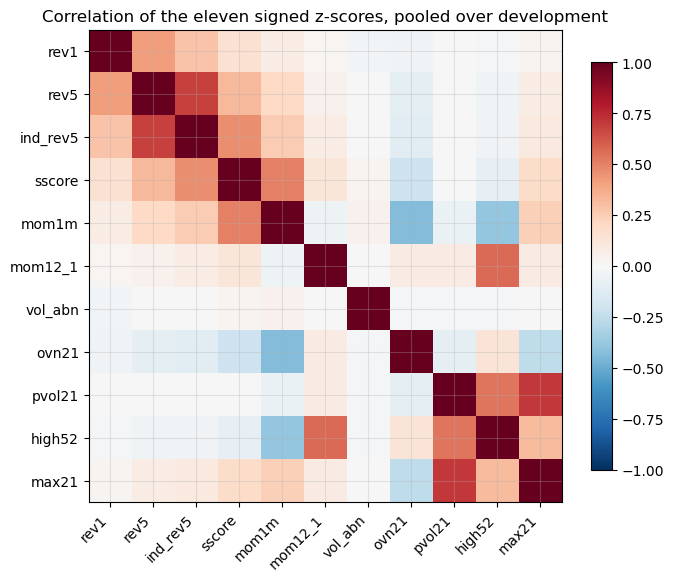

In [8]:
coverage = panel[ALPHAS].notna().mean().rename("coverage")
display(coverage.to_frame())
print(f"mean development-period joint-model R^2: {panel.loc[panel['date'] <= DEV_END, 'r2_joint'].mean():.3f}")
print(f"factor count in the combined risk model: {N_FACTORS} PCA + {len(ETF9)} sector ETFs = "
      f"{N_FACTORS + len(ETF9)}")

dev_panel = panel[panel["date"] <= DEV_END]
corr = dev_panel[ALPHAS].corr()
display(corr.round(2))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(ALPHAS))); ax.set_xticklabels(ALPHAS, rotation=45, ha="right")
ax.set_yticks(range(len(ALPHAS))); ax.set_yticklabels(ALPHAS)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation of the eleven signed z-scores, pooled over development")
plt.tight_layout(); plt.show()

## 4. Univariate information coefficients

Notebook 12's probe-day estimator: every fifth session of the trading range is a probe day, so
non-overlapping windows back the five-day target's standard error. For each alpha, horizon and
period, the Pearson correlation between the signed z-score and the hedged forward target is computed
per probe day (pairwise-complete, requiring more than 30 names), and averaged; the standard error is
that day-level standard deviation over the square root of the probe-day count, and `t` is the ratio.
The Benjamini-Hochberg verdict at q = 0.10 is computed once, across the eleven alphas' development
h = 5 p-values.

In [9]:
PROBE = set(trade_sessions[::5])
panel["probe"] = panel["date"].isin(PROBE)
probe_panel = panel[panel["probe"]]
print(f"{len(PROBE):,} probe days of {trade_sessions.nunique():,} trading-range sessions")

PERIODS = {"dev": (panel["date"] <= DEV_END),
           "test": (panel["date"] >= TEST_START) & (panel["date"] <= TEST_END),
           "hold": (panel["date"] >= HOLD_START)}

def ic_for(mask, alpha, fwd):
    sub = probe_panel[mask.reindex(probe_panel.index, fill_value=False)]
    def day_ic(g):
        m = g[alpha].notna() & g[fwd].notna()
        return np.corrcoef(g.loc[m, alpha], g.loc[m, fwd])[0, 1] if m.sum() > 30 else np.nan
    per_day = sub.groupby("date").apply(day_ic).dropna()
    a = per_day.to_numpy()
    if len(a) < 2:
        return dict(ic=np.nan, se=np.nan, t=np.nan, n=len(a))
    ic, sd = a.mean(), a.std(ddof=1)
    se = sd / np.sqrt(len(a))
    return dict(ic=ic, se=se, t=ic / se if se > 0 else np.nan, n=len(a))

ic_rows = {}
for a in ALPHAS:
    r = {"alpha": a}
    for p, mask in PERIODS.items():
        got = ic_for(mask, a, "fwd5")
        r[f"{p}_ic"], r[f"{p}_se"], r[f"{p}_t"], r[f"{p}_n"] = got["ic"], got["se"], got["t"], got["n"]
    r["sign_agrees_dev"] = bool(r["dev_ic"] > 0)
    ic_rows[a] = r
ic5 = pd.DataFrame(ic_rows).T.set_index("alpha")

dev_p = 2 * stats.t.sf(np.abs(ic5["dev_t"].astype(float)), df=(ic5["dev_n"].astype(float) - 1))
reject, p_adj = benjamini_hochberg_fdr(dev_p, alpha=0.10)
ic5["bh_pass_dev"] = reject

display(ic5.round(4))
print(f"development h=5 ICs with the pre-registered sign: {int(ic5['sign_agrees_dev'].sum())} of {len(ALPHAS)}")
print(f"Benjamini-Hochberg (q=0.10) survivors among the eleven development h=5 ICs: "
      f"{int(ic5['bh_pass_dev'].sum())} of {len(ALPHAS)}")

987 probe days of 4,934 trading-range sessions


,dev_ic,dev_se,dev_t,dev_n,test_ic,test_se,test_t,test_n,hold_ic,hold_se,hold_t,hold_n,sign_agrees_dev,bh_pass_dev
alpha,,,,,,,,,,,,,,
rev1,0.011451,0.003452,3.317617,504,0.006256,0.004526,1.382334,352,0.008965,0.007567,1.184698,127,True,True
rev5,0.011456,0.003608,3.175067,504,0.001523,0.00462,0.329576,352,0.0143,0.007784,1.837022,127,True,True
ind_rev5,0.002836,0.004276,0.663328,504,0.010082,0.005223,1.930131,352,0.000044,0.007934,0.005603,127,True,False
sscore,0.004742,0.003328,1.424801,504,0.006856,0.003977,1.724008,352,-0.001112,0.006351,-0.175148,127,True,False
mom1m,0.002984,0.00391,0.7633,504,0.002321,0.004902,0.473424,352,0.001361,0.007486,0.181825,127,True,False
mom12_1,0.004026,0.003122,1.289455,504,0.001513,0.003983,0.379913,352,0.006279,0.006179,1.016288,127,True,False
vol_abn,0.001354,0.002513,0.538929,504,0.002888,0.002987,0.96698,352,-0.007368,0.004813,-1.530935,127,True,False
ovn21,0.003838,0.003086,1.243521,504,-0.003874,0.004185,-0.925722,352,-0.007537,0.006891,-1.093699,127,True,False
pvol21,0.002337,0.002813,0.830556,504,-0.004059,0.003454,-1.175027,352,-0.005082,0.006141,-0.827629,127,True,False


development h=5 ICs with the pre-registered sign: 9 of 11
Benjamini-Hochberg (q=0.10) survivors among the eleven development h=5 ICs: 2 of 11


### 4.1 Other horizons, and the decay figure

The same estimator at h = 1 and h = 21 (reported, never selected on), and a development-vs-test
comparison at h = 5.

h = 1:


,dev_ic,dev_t,dev_n,test_ic,test_t,test_n,hold_ic,hold_t,hold_n
alpha,,,,,,,,,
rev1,0.005382,1.50459,504,0.006253,1.324028,352,0.003152,0.456284,127
rev5,0.000771,0.216221,504,0.007916,1.703413,352,-0.00143,-0.183655,127
ind_rev5,-0.007585,-1.72813,504,0.01117,2.074562,352,0.005103,0.611888,127
sscore,0.002428,0.73428,504,0.001864,0.448275,352,-0.00995,-1.502509,127
mom1m,-0.005859,-1.546863,504,0.005402,1.092463,352,-0.009207,-1.233894,127
mom12_1,0.000732,0.2389,504,0.002732,0.671653,352,-0.001944,-0.303046,127
vol_abn,-0.000407,-0.153716,504,0.002497,0.713681,352,-0.001417,-0.243871,127
ovn21,0.009138,3.007134,504,-0.003745,-0.933945,352,0.007709,1.170806,127
pvol21,0.000334,0.124747,504,-0.000843,-0.242501,352,0.004351,0.64009,127


h = 21:


,dev_ic,dev_t,dev_n,test_ic,test_t,test_n,hold_ic,hold_t,hold_n
alpha,,,,,,,,,
rev1,0.005775,1.745244,504,0.001144,0.263406,352,0.002875,0.351707,127
rev5,0.008587,2.415653,504,0.00081,0.187753,352,0.006881,0.977226,127
ind_rev5,0.007822,1.92262,504,0.001776,0.354306,352,0.000448,0.052261,127
sscore,0.008812,2.71113,504,0.006222,1.563704,352,-0.011969,-1.86998,127
mom1m,0.006198,1.535084,504,-0.000281,-0.056202,352,-0.021124,-2.961882,127
mom12_1,0.004988,1.632015,504,0.000733,0.176116,352,0.012707,2.186119,127
vol_abn,-0.001954,-0.862923,504,0.003507,1.156791,352,-0.00874,-1.601169,127
ovn21,0.006688,2.27707,504,-0.001652,-0.401454,352,-0.004205,-0.636569,127
pvol21,-0.003839,-1.442589,504,-0.009031,-2.419031,352,-0.018402,-2.788255,127


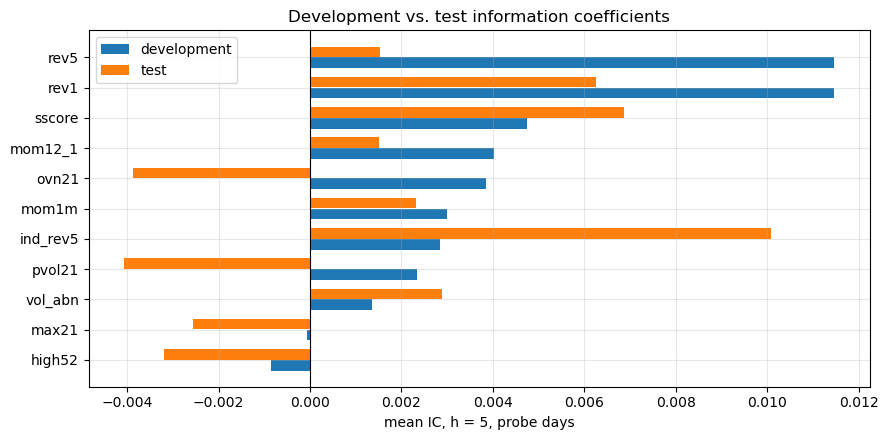

In [10]:
def ic_table_h(fwd):
    out = {}
    for a in ALPHAS:
        r = {"alpha": a}
        for p, mask in PERIODS.items():
            got = ic_for(mask, a, fwd)
            r[f"{p}_ic"], r[f"{p}_t"], r[f"{p}_n"] = got["ic"], got["t"], got["n"]
        out[a] = r
    return pd.DataFrame(out).T.set_index("alpha")

ic1, ic21 = ic_table_h("fwd1"), ic_table_h("fwd21")
print("h = 1:")
display(ic1.round(4))
print("h = 21:")
display(ic21.round(4))

fig, ax = plt.subplots(figsize=(9, 4.5))
o = ic5.sort_values("dev_ic")
ax.barh(np.arange(len(o)) - 0.18, o["dev_ic"], height=0.35, label="development", color="tab:blue")
ax.barh(np.arange(len(o)) + 0.18, o["test_ic"], height=0.35, label="test", color="tab:orange")
ax.set_yticks(range(len(o))); ax.set_yticklabels(o.index)
ax.axvline(0, color="k", lw=0.8); ax.legend(); ax.set_xlabel("mean IC, h = 5, probe days")
ax.set_title("Development vs. test information coefficients")
plt.tight_layout(); plt.show()

## 5. Blends

**Equal-weight**: the row-wise mean of the eleven signed z-scores each day (`np.nanmean`, so a name
missing `ind_rev5`/`sscore` is blended from the other alphas rather than dropped outright — the
alternative, dropping any name without all eleven, would remove exactly the names the sector
assignment could not cover, which is not what the pre-registration's "mean of the eleven" was meant
to exclude).

**Ridge**: the h = 5 hedged target regressed on the eleven z-scores, fit on the trailing 36 months of
daily (name, day) rows pooled together, refit at the first session of every calendar month, walk
forward. The penalty grid {0.1, 1, 10, 100} (times the training fold's own mean diagonal of
:math:`X^\top X`) is chosen by leave-one-calendar-year-out cross-validation strictly inside the
trailing 36-month window; the final fit for the month uses the whole window at the chosen penalty.
To keep the walk forward honest, a refit at month *m* only uses history whose own five-day target is
fully resolved before month *m* begins (a session's row is excluded from history until 5 sessions
after it, so no refit ever sees a not-yet-realized target). Missing z-scores are filled with 0 in the
design matrix, matching the blend's own equal-weight treatment.

**Where the blend disagrees with the univariate sign.** The ridge coefficients act on the already
signed z-scores, so a negative refit coefficient means the blend has decided that alpha should point
the other way from its pre-registered `SIGN` that month. The table after the ridge-weight plot below
gives, per alpha, the share of the 222 monthly refits with a negative coefficient and whether the median
coefficient over all refits disagrees in sign with the pre-registered `SIGN`. The median, not the mean: the
few refits that chose the lightest penalty carry coefficients an order of magnitude larger than the rest
and would decide a mean by themselves.

In [11]:
month_start = panel["date"].dt.to_period("M")
first_of_month = panel.groupby(month_start)["date"].min().sort_values()
refit_dates = list(first_of_month)

by_date = {d: g for d, g in panel.groupby("date")}
date_list = sorted(by_date)
date_pos = {d: i for i, d in enumerate(date_list)}

def design(dates):
    Xs, ys = [], []
    for d in dates:
        g = by_date[d]
        X = g[ALPHAS].fillna(0.0).to_numpy()
        y = g["fwd5"].to_numpy()
        ok = np.isfinite(y)
        if ok.sum():
            Xs.append(X[ok]); ys.append(y[ok])
    if not Xs:
        return np.zeros((0, len(ALPHAS))), np.zeros(0)
    return np.vstack(Xs), np.concatenate(ys)

def ridge_fit(X, y, lam):
    XtX = X.T @ X
    return np.linalg.solve(XtX + lam * np.eye(X.shape[1]), X.T @ y)

def choose_lambda(dates_by_year):
    years = sorted(dates_by_year)
    if len(years) < 2:
        return RIDGE_GRID[1]
    scores = {}
    for mult in RIDGE_GRID:
        mses = []
        for held in years:
            train_dates = [d for y in years if y != held for d in dates_by_year[y]]
            Xtr, ytr = design(train_dates)
            Xte, yte = design(dates_by_year[held])
            if len(ytr) < 50 or len(yte) < 10:
                continue
            lam = mult * np.mean(np.diag(Xtr.T @ Xtr))
            coef = ridge_fit(Xtr, ytr, lam)
            mses.append(float(np.mean((yte - Xte @ coef) ** 2)))
        if mses:
            scores[mult] = float(np.mean(mses))
    return min(scores, key=scores.get) if scores else RIDGE_GRID[1]

t0 = time.time()
RIDGE_COEF = {}
LAMBDA_LOG = []
for refit_d in refit_dates:
    i_refit = date_pos[refit_d]
    trail_start = refit_d - pd.DateOffset(months=RIDGE_TRAIL_MONTHS)
    hist_dates = [d for d in date_list if trail_start <= d < refit_d and date_pos[d] + 5 < i_refit]
    if len(hist_dates) < 252:            # need at least a year of trailing history to fit anything
        continue
    by_year = {}
    for d in hist_dates:
        by_year.setdefault(d.year, []).append(d)
    mult = choose_lambda(by_year)
    Xall, yall = design(hist_dates)
    lam = mult * np.mean(np.diag(Xall.T @ Xall))
    coef = ridge_fit(Xall, yall, lam)
    RIDGE_COEF[refit_d] = coef
    LAMBDA_LOG.append({"refit": refit_d, "lambda_mult": mult, "n_rows": len(yall)})

lambda_log = pd.DataFrame(LAMBDA_LOG)
print(f"ridge: {len(RIDGE_COEF)} monthly refits over {len(refit_dates)} calendar months, "
      f"built in {time.time() - t0:.0f}s")
print(f"first ridge refit: {lambda_log['refit'].min().date() if len(lambda_log) else 'none'}")
display(lambda_log["lambda_mult"].value_counts().to_frame("n refits"))

ridge: 222 monthly refits over 235 calendar months, built in 571s
first ridge refit: 2007-02-01


,n refits
lambda_mult,
100.0,90
1.0,72
10.0,47
0.1,13


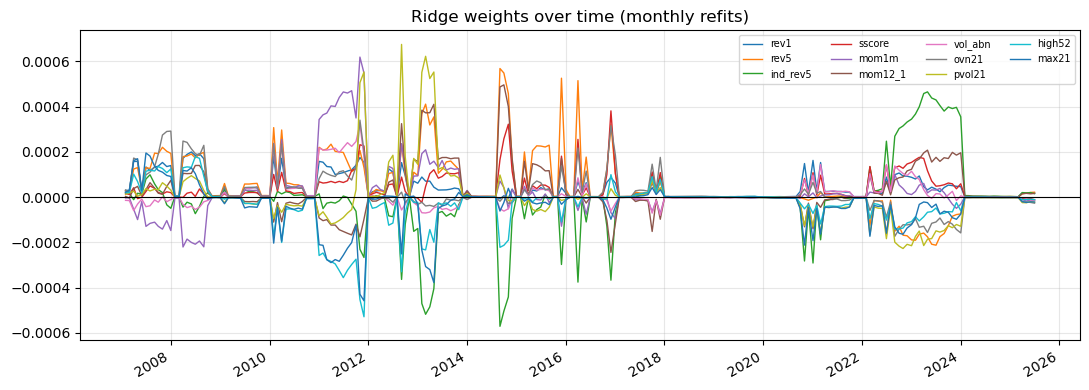

,share of refits with coef < 0,median coefficient (bps per z),median coef disagrees with SIGN
max21,0.730,-0.041,True
high52,0.640,-0.029,True
pvol21,0.572,-0.013,True
vol_abn,0.491,0.000,False
ind_rev5,0.486,0.001,False
mom12_1,0.468,0.011,False
mom1m,0.441,0.012,False
ovn21,0.383,0.022,False
rev5,0.275,0.045,False
sscore,0.095,0.103,False


9 of 11 alphas have a negative ridge coefficient (disagreeing with the pre-registered univariate sign) in more than a quarter of monthly refits: ['max21', 'high52', 'pvol21', 'vol_abn', 'ind_rev5', 'mom12_1', 'mom1m', 'ovn21', 'rev5']
alphas whose MEDIAN ridge coefficient disagrees in sign with the pre-registered SIGN: ['max21', 'high52', 'pvol21']


ridge blend has a fitted score on 4,641 of 4,912 sessions (burn-in before the first refit gets a flat zero score, i.e. no position)


In [12]:
fig, ax = plt.subplots(figsize=(11, 4))
if RIDGE_COEF:
    coef_df = pd.DataFrame(RIDGE_COEF, index=ALPHAS).T
    coef_df.plot(ax=ax, lw=1.0)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title("Ridge weights over time (monthly refits)")
    ax.legend(fontsize=7, ncol=4)
plt.tight_layout(); plt.show()

# Where the ridge blend disagrees with the pre-registered univariate sign (confirmed audit finding
# F5): coefficients act on already-signed z-scores, so a negative refit coefficient is a disagreement
# with SIGN for that alpha in that month. Table the share of refits with a negative coefficient per
# alpha, and the sign of the mean coefficient, and say so in prose.
if RIDGE_COEF:
    neg_share = (coef_df < 0).mean().rename("share of refits with coef < 0")
    # coefficients act on z-scores that already carry SIGN, so agreement is a POSITIVE coefficient
    # and a disagreement is a negative one; shown in bps of 5-session return per unit z-score
    med_coef = (coef_df.median() * 1e4).rename("median coefficient (bps per z)")
    sign_table = pd.concat([neg_share, med_coef], axis=1)
    sign_table["median coef disagrees with SIGN"] = sign_table["median coefficient (bps per z)"] < 0
    sign_table = sign_table.sort_values("share of refits with coef < 0", ascending=False)
    display(sign_table.round(3))
    flipped = sign_table.index[sign_table["share of refits with coef < 0"] > 0.25].tolist()
    print(f"{len(flipped)} of {len(ALPHAS)} alphas have a negative ridge coefficient (disagreeing with "
          f"the pre-registered univariate sign) in more than a quarter of monthly refits: {flipped}")
    med_flipped = sign_table.index[sign_table["median coef disagrees with SIGN"]].tolist()
    print(f"alphas whose MEDIAN ridge coefficient disagrees in sign with the pre-registered SIGN: "
          f"{med_flipped}")

# assign each day the most recently fitted coefficient vector (None before the first refit)
sorted_refits = sorted(RIDGE_COEF)
coef_for_day = {}
cur = None
ri = 0
for d in date_list:
    while ri < len(sorted_refits) and sorted_refits[ri] <= d:
        cur = sorted_refits[ri]
        ri += 1
    coef_for_day[d] = cur

EW_SCORE, RIDGE_SCORE = {}, {}
for d in date_list:
    g = by_date[d]
    Z = g[ALPHAS].to_numpy()
    ew = np.nanmean(Z, axis=1)
    EW_SCORE[d] = pd.Series(ew, index=g["name"].to_numpy())
    c = coef_for_day[d]
    if c is not None:
        rs = np.nan_to_num(Z, nan=0.0) @ RIDGE_COEF[c]
        RIDGE_SCORE[d] = pd.Series(rs, index=g["name"].to_numpy())
    else:
        RIDGE_SCORE[d] = pd.Series(0.0, index=g["name"].to_numpy())

n_ridge_days = sum(1 for d in date_list if coef_for_day[d] is not None)
print(f"ridge blend has a fitted score on {n_ridge_days:,} of {len(date_list):,} sessions "
      f"(burn-in before the first refit gets a flat zero score, i.e. no position)")

## 6. Portfolio construction

Target weights are `neutralize(blend score, B_day) * CAP` (notebook 12's `neutralize`, with this
notebook's combined loadings `B_day` -- 15 PCA + 9 sector-ETF betas + one size
column, cached above as `desk_loadings.pkl`). Held weights move a fraction phi of the gap to target
each session (Garleanu-Pedersen partial adjustment), then the book is rescaled back to CAP gross,
exactly as notebook 12's `run`. Positions taken at the close of session t earn session t+1's return.
Eight books: two blends times four phi values (0.25 primary, {1, 0.5, 0.1} sensitivity).

In [13]:
def build_targets(score_by_day):
    tgt = {}
    for d, s in score_by_day.items():
        cols, B = LOADINGS[d]
        s = s.reindex(cols).fillna(0.0).to_numpy()
        tgt[d] = pd.Series(neutralize(s, B.astype(np.float64)), index=cols) * CAP
    return tgt

t0 = time.time()
TARGETS = {"ew": build_targets(EW_SCORE), "ridge": build_targets(RIDGE_SCORE)}
print(f"target weights built for {len(TARGETS['ew']):,} sessions x 2 blends in {time.time()-t0:.0f}s")

def portfolio(tgt_by_day, phi):
    w_prev, rows = pd.Series(dtype=float), []
    for d in date_list:
        t = tgt_by_day.get(d)
        if t is None:
            continue
        idx = t.index.union(w_prev.index)
        t_al, p_al = t.reindex(idx).fillna(0.0), w_prev.reindex(idx).fillna(0.0)
        w = p_al + phi * (t_al - p_al)
        g = w.abs().sum()
        if g > 0:
            w = w * (CAP / g)
        rows.append((d, w))
        w_prev = w[w.abs() > 1e-9]
    return dict(rows)

PORT = {(b, phi): portfolio(TARGETS[b], phi) for b in ("ew", "ridge") for phi in PHIS}
print(f"built {len(PORT)} books")

target weights built for 4,912 sessions x 2 blends in 2s


built 8 books


## 7. Costs and metrics

Stock costs are notebook 12 section 5.5's measured per-(ticker, year) rates
(`cache/xs_costs.parquet`, read-only), with a flat 5 bps a leg-side as the comparison basis; borrow
is 50 bp/year on the short leg's dollar notional, accrued daily (notebook 11's convention, via
`pairs.strategies.evaluate`'s formula, reproduced here since this book has no round-trip ledger for
that module's own function to consume). Sharpe is reported with standard error
:math:`\sqrt{252/\text{sessions}}`, matching the pre-registration; this is the plain form (no
skew/kurtosis correction), which is also what section 9's like-for-like comparison to notebook 11's
0.49 +/- 0.26 requires.

In [14]:
cost_cells = pd.read_parquet(CACHE / "xs_costs.parquet")
cost_ok = cost_cells[cost_cells["err"].eq("")]
COST = {int(y): g.set_index("ticker")["cost_used"] for y, g in cost_ok.groupby("year")}
MED = {y: float(v.median()) for y, v in COST.items()}
print(f"stock costs reused from notebook 12: {len(cost_ok):,} of {len(cost_cells):,} "
      f"(ticker, year) cells measured, median {cost_ok['cost_used'].median():.2f} bps")

FWD1 = {d: ret.loc[date_list[i + 1]] if i + 1 < len(date_list) else None
        for i, d in enumerate(date_list)}

def run_book(pos_by_day, cost_bps=None):
    # cost_bps=None uses the measured per-(ticker, year) rate; a float charges that flat rate instead.
    # Rows are labeled by the REALIZATION date, date_list[i+1] -- the session the position (set at the
    # close of d) actually earns its P&L on -- matching factor_mimicking_raw below (confirmed audit
    # finding F1). Labeling by the set date d, as the original code did, misaligned every downstream
    # regression, by-year table and period cut by one session; costs and turnover are charged on the
    # session the trade is placed (d) but still attributed to the row for the session the P&L lands on.
    prev, rows = pd.Series(dtype=float), []
    for i, d in enumerate(date_list):
        w = pos_by_day.get(d)
        if w is None:
            continue
        idx = w.index.union(prev.index)
        w_now, w_prev = w.reindex(idx).fillna(0.0), prev.reindex(idx).fillna(0.0)
        dw = (w_now - w_prev).abs()
        traded = float(dw.sum())
        if cost_bps is None:
            c = COST.get(d.year, pd.Series(dtype=float)).reindex(idx)
            fb = MED.get(d.year, cost_ok["cost_used"].median())
            cost = float((dw * c.fillna(fb)).sum()) / 1e4
        else:
            cost = traded * cost_bps / 1e4
        short_notional = float(-w_now[w_now < 0].sum())
        borrow = short_notional * (BORROW_BPS / 1e4) / ANN
        r = FWD1.get(d)
        prev = w_now[w_now.abs() > 1e-9]
        if i + 1 >= len(date_list):
            continue  # no realization date for the last session's position: drop, don't mislabel
        gross = float((w_now * r.reindex(idx).fillna(0.0)).sum()) if r is not None else 0.0
        rows.append({"date": date_list[i + 1], "pnl_gross": gross, "cost": cost, "borrow": borrow,
                     "pnl": gross - cost - borrow, "traded": traded,
                     "gross": float(w_now.abs().sum()), "n": int((w_now.abs() > 1e-9).sum())})
    return pd.DataFrame(rows).set_index("date")

t0 = time.time()
BOOKS = {k: run_book(v) for k, v in PORT.items()}
BOOKS_FLAT = {k: run_book(v, cost_bps=COST_BPS) for k, v in PORT.items()}
print(f"{len(BOOKS)} books evaluated at measured cost and at flat {COST_BPS:g} bps in {time.time()-t0:.0f}s")

stock costs reused from notebook 12: 11,913 of 11,992 (ticker, year) cells measured, median 1.98 bps


8 books evaluated at measured cost and at flat 5 bps in 39s


In [15]:
def se_sharpe(n):
    return float(np.sqrt(ANN / n)) if n > 0 else np.nan

def summarize(k):
    d, dflat = BOOKS[k], BOOKS_FLAT[k]
    n = len(d)
    def period_sharpe(mask_start=None, mask_end=None):
        sel = d
        if mask_start is not None:
            sel = sel[sel.index >= mask_start]
        if mask_end is not None:
            sel = sel[sel.index <= mask_end]
        return sharpe(sel["pnl"] / CAP), len(sel)
    s_dev, n_dev = period_sharpe(mask_end=DEV_END)
    s_test, n_test = period_sharpe(TEST_START, TEST_END)
    s_hold, n_hold = period_sharpe(HOLD_START)
    gross_nz = d["gross"].replace(0, np.nan)
    return {
        "blend": k[0], "phi": k[1],
        "gross_sharpe_all": sharpe(d["pnl_gross"] / CAP),
        "net_measured_sharpe_all": sharpe(d["pnl"] / CAP),
        "net_flat5_sharpe_all": sharpe((dflat["pnl_gross"] - dflat["cost"] - dflat["borrow"]) / CAP),
        "se_all": se_sharpe(n),
        "turnover_per_session": float((d["traded"] / gross_nz).mean()),
        "breakeven_bps": float(d["pnl_gross"].sum() / d["traded"].sum() * 1e4),
        "net_measured_sharpe_dev": s_dev, "net_measured_sharpe_test": s_test,
        "net_measured_sharpe_hold": s_hold,
        "net_measured_t_test": (s_test * np.sqrt(n_test / ANN)) if np.isfinite(s_test) else np.nan,
    }

summary = pd.DataFrame([summarize(k) for k in BOOKS]).set_index(["blend", "phi"])
display(summary.round(4))

gross_sharpe_all  net_measured_sharpe_all  net_flat5_sharpe_all  \
blend phi                                                                     
ew    0.25            1.1455                   0.5964                0.2056   
      1.00            1.4978                  -0.2269               -1.6272   
      0.50            1.2641                   0.3457               -0.3614   
      0.10            1.0696                   0.7741                0.5992   
ridge 0.25            0.5295                   0.0715               -0.2456   
      1.00            0.7959                  -0.6680               -1.8208   
      0.50            0.5889                  -0.1902               -0.7724   
      0.10            0.4319                   0.1939                0.0556   

            se_all  turnover_per_session  breakeven_bps  \
blend phi                                                 
ew    0.25  0.2265                0.1865         6.7422   
      1.00  0.2265                0.6825         2.4670   
      0.50  0.2265                0.3408         4.1149   
      0.10  0.2265                0.0845        14.0387   
ridge 0.25  0.2265                0.1806         3.7913   
      1.00  0.2265                0.6426         1.5682   
      0.50  0.2265                0.3266         2.2949   
      0.10  0.2265                0.0828         7.1139   

            net_measured_sharpe_dev  net_measured_sharpe_test  \
blend phi                                                       
ew    0.25                   0.9915                    0.1165   
      1.00                   0.1407                   -0.6899   
      0.50                   0.7552                   -0.1945   
      0.10                   1.0921                    0.3892   
ridge 0.25                   0.5524                   -0.5047   
      1.00                  -0.1985                   -1.2709   
      0.50                   0.3241                   -0.8336   
      0.10                   0.5111                   -0.2338   

            net_measured_sharpe_hold  net_measured_t_test  
blend phi                                                  
ew    0.25                    0.4387               0.3081  
      1.00                   -0.3773              -1.8244  
      0.50                    0.2635              -0.5143  
      0.10                    0.6992               1.0292  
ridge 0.25                   -0.0547              -1.3346  
      1.00                   -0.6683              -3.3605  
      0.50                   -0.2233              -2.2043  
      0.10                    0.2348              -0.6182

### 7.1 P&L by year and by period

,gross Sharpe,net Sharpe,P&L ($k)
date,,,
2006,NaN,NaN,0.000
2007,3.293,2.822,80.590
2008,1.674,1.294,65.524
2009,1.326,0.663,26.117
2010,-0.239,-0.978,-23.982
2011,-0.463,-0.826,-24.949
2012,0.537,0.059,1.596
2013,0.408,-0.160,-3.345
2014,1.545,0.995,20.943


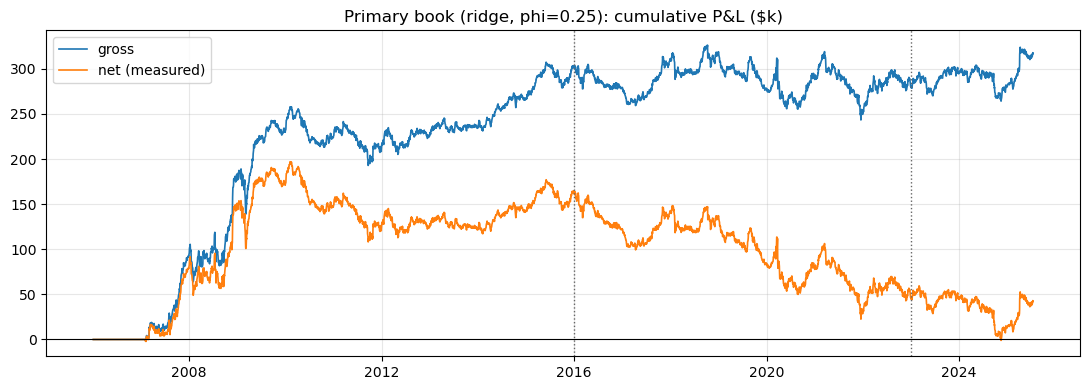

In [16]:
primary = ("ridge", PHI_PRIMARY)
ew_primary = ("ew", PHI_PRIMARY)
d = BOOKS[primary]
# BOOKS[k] is indexed by the realization date (date_list[i+1], the session the position set at d's
# close actually earns its P&L on) rather than the set date d (F1's fix) -- so this by-year table is
# already the corrected, regrouped one.
by_year = d.groupby(d.index.year).apply(lambda g: pd.Series({
    "gross Sharpe": sharpe(g["pnl_gross"] / CAP), "net Sharpe": sharpe(g["pnl"] / CAP),
    "P&L ($k)": g["pnl"].sum() / 1e3}))
display(by_year.round(3))

fig, ax = plt.subplots(figsize=(11, 4))
eq_gross = d["pnl_gross"].cumsum() / 1e3
eq_net = d["pnl"].cumsum() / 1e3
ax.plot(eq_gross.index, eq_gross, label="gross", lw=1.2)
ax.plot(eq_net.index, eq_net, label="net (measured)", lw=1.2)
ax.axvline(DEV_END, color="0.4", ls=":", lw=1); ax.axvline(TEST_END, color="0.4", ls=":", lw=1)
ax.axhline(0, color="k", lw=0.8); ax.legend()
ax.set_title(f"Primary book (ridge, phi={PHI_PRIMARY}): cumulative P&L ($k)")
plt.tight_layout(); plt.show()

### 7.2 Factor exposures, both books (primary phi = 0.25)

Pre-registered per book (two blends x primary phi), not for the ridge book alone (confirmed audit
finding F4): each book's daily net returns regressed on SPY, the nine sector ETFs, a size
factor-mimicking return (yesterday's robust size z-score dotted into today's cross-section of
returns, dollar-neutral, unit gross) and a 12-1 momentum factor-mimicking return built the same way
from `mom12_1`'s own z-score. Momentum is not neutralized in the portfolio construction (it is an
alpha under test, per the pre-registration), so its exposure here is a measurement, not a
residual-by-construction zero. `BOOKS[k]` is now indexed by the realization date (the fix for F1), so
it lines up with the factor-mimicking returns below without a manual re-index.

In [17]:
def factor_mimicking_raw(raw_panel):
    # size and momentum factor-mimicking returns use each day's own (unsigned, pre-sign)
    # characteristic, rebuilt from the raw panels rather than the already-signed alpha column.
    rows = {}
    for d in date_list:
        g = by_date[d]
        names = g["name"].to_numpy()
        z = raw_panel.loc[d, names].to_numpy() if d in raw_panel.index else np.full(len(names), np.nan)
        z = robust_z(z)
        ok = np.isfinite(z)
        if ok.sum() < 10:
            continue
        w = z[ok] - np.nanmean(z[ok]); gsum = np.abs(w).sum()
        if gsum < 1e-9:
            continue
        w = w / gsum
        i = date_pos[d]
        if i + 1 >= len(date_list):
            continue
        r_next = ret.loc[date_list[i + 1]].reindex(names[ok]).fillna(0.0).to_numpy()
        rows[date_list[i + 1]] = float((w * r_next).sum())
    return pd.Series(rows)

log_dv = np.log(dv.rolling(21).mean())
mom_factor = factor_mimicking_raw(mom12_1)
size_factor = factor_mimicking_raw(log_dv)

def exposure_table(book_key):
    # BOOKS[book_key] is already labeled by realization date (F1's fix), matching mom_factor/size_factor.
    exposure_df = pd.DataFrame({"book": BOOKS[book_key]["pnl"] / CAP}).dropna()
    X = pd.DataFrame({"SPY": ret["SPY"], **{e: ret[e] for e in ETF9},
                      "size": size_factor, "mom12_1": mom_factor}).reindex(exposure_df.index).fillna(0.0)
    X = sm.add_constant(X)
    model = sm.OLS(exposure_df["book"].to_numpy(), X.to_numpy(), missing="drop").fit()
    return pd.DataFrame({"beta": model.params, "t": model.tvalues}, index=X.columns)

EXPOSURE = {k: exposure_table(k) for k in (primary, ew_primary)}
for k in (primary, ew_primary):
    print(f"exposures, {k[0]} phi={k[1]}:")
    display(EXPOSURE[k].round(3))

exposures, ridge phi=0.25:


,beta,t
const,0.000,0.721
SPY,0.066,4.116
XLB,0.002,0.452
XLE,0.002,0.880
XLF,-0.008,-2.473
XLI,-0.025,-4.416
XLK,-0.018,-2.888
XLP,-0.016,-2.966
XLU,-0.013,-3.791
XLV,-0.010,-1.912


exposures, ew phi=0.25:


,beta,t
const,0.000,1.569
SPY,0.030,2.191
XLB,-0.012,-3.213
XLE,-0.002,-0.854
XLF,-0.000,-0.022
XLI,0.003,0.636
XLK,-0.001,-0.271
XLP,0.030,6.428
XLU,0.005,1.671
XLV,0.004,1.022


### 7.3 The five-clause scorecard, both books (primary phi = 0.25)

Adapted from notebook 14 section 9.3 to a daily cross-sectional book: the independent-bet unit there
was one formation; here it is one non-overlapping five-session block (the same spacing the h = 5
probe-day IC estimator uses), since trades inside one block share almost all of the same five-day
hedged target. Clause (b) is scored against the eleven alphas actually tested in this pre-registered
design (no post-hoc search was performed; the whole point of pre-registering is that there is nothing
else to correct for). Computed for both blends at the primary phi (confirmed audit finding F4), not
the ridge book alone.

In [18]:
def scorecard_for(book_key):
    d = BOOKS[book_key].copy()
    d["block"] = (np.arange(len(d)) // 5)
    net_bps = (d["pnl"] / d["traded"].replace(0, np.nan) * 1e4)
    gross_bps = (d["pnl_gross"] / d["traded"].replace(0, np.nan) * 1e4)
    cost_bps_series = ((d["cost"] + d["borrow"]) / d["traded"].replace(0, np.nan) * 1e4)
    block_net = net_bps.groupby(d["block"]).mean().dropna()
    t_bets = float(block_net.mean() / (block_net.std(ddof=1) / np.sqrt(len(block_net))))
    n_alphas_tested = len(ALPHAS)
    t_needed = float(stats.norm.ppf(1 - (1 - 0.95 ** (1 / n_alphas_tested)) / 2))
    net_pnl_span = d["pnl"].sum()
    years_span = len(d) / ANN
    return pd.DataFrame([
        {"clause": "(0) profit per bet beats cost per bet",
         "value": f"{gross_bps.mean():.2f} bps gross vs {cost_bps_series.mean():.2f} bps cost "
                  f"({gross_bps.mean() / cost_bps_series.mean():.2f}x)"},
        {"clause": "(a) survives its own sampling error",
         "value": f"t = {t_bets:.2f} over {len(block_net):,} non-overlapping 5-session blocks"},
        {"clause": "(b) survives the search that found it",
         "value": f"t = {t_needed:.2f} needed for one of {n_alphas_tested} pre-registered alphas (Sidak); "
                  f"achieved t = {t_bets:.2f}"},
        {"clause": "(c) survives out of sample",
         "value": f"test-period net Sharpe {summary.loc[book_key, 'net_measured_sharpe_test']:.3f}, "
                  f"hold-out {summary.loc[book_key, 'net_measured_sharpe_hold']:.3f}"},
        {"clause": "(d) large enough to be worth running",
         "value": f"${net_pnl_span:,.0f} net P&L over {years_span:.1f} years on a ${CAP:,.0f} book"},
    ]).set_index("clause")

SCORECARD = {k: scorecard_for(k) for k in (primary, ew_primary)}
for k in (primary, ew_primary):
    print(f"five-clause scorecard, {k[0]} phi={k[1]}:")
    display(SCORECARD[k])

five-clause scorecard, ridge phi=0.25:


,value
clause,
(0) profit per bet beats cost per bet,3.40 bps gross vs 3.28 bps cost (1.04x)
(a) survives its own sampling error,t = 0.11 over 929 non-overlapping 5-session bl...
(b) survives the search that found it,t = 2.83 needed for one of 11 pre-registered a...
(c) survives out of sample,"test-period net Sharpe -0.505, hold-out -0.055"
(d) large enough to be worth running,"$42,898 net P&L over 19.5 years on a $1,000,00..."


five-clause scorecard, ew phi=0.25:


,value
clause,
(0) profit per bet beats cost per bet,6.77 bps gross vs 3.23 bps cost (2.10x)
(a) survives its own sampling error,t = 2.74 over 983 non-overlapping 5-session bl...
(b) survives the search that found it,t = 2.83 needed for one of 11 pre-registered a...
(c) survives out of sample,"test-period net Sharpe 0.116, hold-out 0.439"
(d) large enough to be worth running,"$321,487 net P&L over 19.5 years on a $1,000,0..."


### 7.4 ETF share of the "liquid US names" cross-section

`universe_at` (Section 1.2) excludes only the nine sector ETFs and SPY from the equity universe; it is
exactly notebook 12's screen, applied verbatim, so this is a pre-registered premise, not a deviation.
But the liquidity screen alone does not know an ETF from a stock, so leveraged, inverse, country and
commodity ETFs pass through it and are traded like any other name (confirmed skeptic finding S4).
The list below is a hand-curated, partial identification of such tickers (not a complete list -- the
audit that raised this finding matched against roughly 141 tickers; this is illustrative of the same
categories, not a claim of completeness), used only to disclose their share of the book and to report
an ex-these-names sensitivity. Reversal and sector-residual alphas are not well defined on paired
leveraged/inverse ETFs (e.g. a 2x long and a 2x short index fund), which is a premise the
pre-registration did not name.

In [19]:
# Hand-curated, illustrative, not exhaustive -- see the markdown above.
ETF_LIKE = {
    "EWZ", "EEM", "FXI", "EWJ", "EWW", "EWT", "EWY", "EWG", "EWU", "EWA", "EWC", "EWH", "EWS", "EWL",
    "EWQ", "EWI", "EWP", "EWN", "EWD", "EWM", "EWZS", "EFA", "VWO", "USO", "UNG", "UCO", "SCO", "GDX",
    "GDXJ", "SLV", "GLD", "XOP", "XME", "SDS", "SSO", "QLD", "QID", "TQQQ", "SQQQ", "UPRO", "SPXU",
    "SPXL", "SPXS", "TNA", "TZA", "SOXL", "SOXS", "FAS", "FAZ", "ERX", "ERY", "DUG", "DIG", "JNUG",
    "JDST", "NUGT", "DUST", "LABU", "LABD", "TMF", "TMV", "TBT", "TLT", "UVXY", "SVXY", "VXX", "UWM",
    "TWM", "URE", "SRS", "DRN", "DRV", "YINN", "YANG", "EDC", "EDZ", "UPRO", "IWM", "MDY", "DIA",
}
etf_present = sorted(t for t in ret.columns if t in ETF_LIKE)
print(f"{len(etf_present)} of {len(ETF_LIKE)} hand-listed ETF-like tickers found in the return panel: "
      f"{etf_present}")

def etf_gross_traded_share(book_key):
    pos = PORT[book_key]
    prev = pd.Series(dtype=float)
    etf_g = etf_t = tot_g = tot_t = 0.0
    for dd in date_list:
        w = pos.get(dd)
        if w is None:
            continue
        idx = w.index.union(prev.index)
        w_now, w_prev = w.reindex(idx).fillna(0.0), prev.reindex(idx).fillna(0.0)
        dw = (w_now - w_prev).abs()
        is_etf = idx.isin(ETF_LIKE)
        etf_g += float(w_now.abs()[is_etf].sum()); tot_g += float(w_now.abs().sum())
        etf_t += float(dw[is_etf].sum()); tot_t += float(dw.sum())
        prev = w_now[w_now.abs() > 1e-9]
    return (etf_g / tot_g if tot_g else np.nan), (etf_t / tot_t if tot_t else np.nan)

for k in (primary, ew_primary):
    g_share, t_share = etf_gross_traded_share(k)
    print(f"{k[0]} phi={k[1]}: {100*g_share:.1f}% of gross, {100*t_share:.1f}% of traded notional "
          f"is in the hand-listed ETF-like names")

def build_targets_excluding(score_by_day, exclude_set):
    # same as build_targets, but the excluded names are dropped from the universe before neutralize
    # (not merely zeroed), matching the sensitivity's intent: what if these were never tradeable.
    tgt = {}
    for dd, s in score_by_day.items():
        cols, B = LOADINGS[dd]
        keep = ~pd.Index(cols).isin(exclude_set)
        cols_k, B_k = cols[keep], B[keep].astype(np.float64)
        if len(cols_k) < 10:
            continue
        s_k = s.reindex(cols_k).fillna(0.0).to_numpy()
        tgt[dd] = pd.Series(neutralize(s_k, B_k), index=cols_k) * CAP
    return tgt

EX_ETF_SUMMARY = {}
for label, score_by_day in (("ew", EW_SCORE), ("ridge", RIDGE_SCORE)):
    tgt_ex = build_targets_excluding(score_by_day, ETF_LIKE)
    pos_ex = portfolio(tgt_ex, PHI_PRIMARY)
    book_ex = run_book(pos_ex)
    EX_ETF_SUMMARY[label] = {
        "net_sharpe_ex_etf": sharpe(book_ex["pnl"] / CAP),
        "net_sharpe_test_ex_etf": sharpe(book_ex.loc[(book_ex.index >= TEST_START)
                                                      & (book_ex.index <= TEST_END), "pnl"] / CAP),
        "net_sharpe_hold_ex_etf": sharpe(book_ex.loc[book_ex.index >= HOLD_START, "pnl"] / CAP),
    }
ex_etf_df = pd.DataFrame(EX_ETF_SUMMARY).T
ex_etf_df["net_sharpe_incl_etf"] = [summary.loc[("ew", PHI_PRIMARY), "net_measured_sharpe_all"],
                                     summary.loc[("ridge", PHI_PRIMARY), "net_measured_sharpe_all"]]
display(ex_etf_df.round(4))
print("ex-ETF books are a reported sensitivity only (S4); nothing in Sections 4-9 is selected on them.")

79 of 79 hand-listed ETF-like tickers found in the return panel: ['DIA', 'DIG', 'DRN', 'DRV', 'DUG', 'DUST', 'EDC', 'EDZ', 'EEM', 'EFA', 'ERX', 'ERY', 'EWA', 'EWC', 'EWD', 'EWG', 'EWH', 'EWI', 'EWJ', 'EWL', 'EWM', 'EWN', 'EWP', 'EWQ', 'EWS', 'EWT', 'EWU', 'EWW', 'EWY', 'EWZ', 'EWZS', 'FAS', 'FAZ', 'FXI', 'GDX', 'GDXJ', 'GLD', 'IWM', 'JDST', 'JNUG', 'LABD', 'LABU', 'MDY', 'NUGT', 'QID', 'QLD', 'SCO', 'SDS', 'SLV', 'SOXL', 'SOXS', 'SPXL', 'SPXS', 'SPXU', 'SQQQ', 'SRS', 'SSO', 'SVXY', 'TBT', 'TLT', 'TMF', 'TMV', 'TNA', 'TQQQ', 'TWM', 'TZA', 'UCO', 'UNG', 'UPRO', 'URE', 'USO', 'UVXY', 'UWM', 'VWO', 'VXX', 'XME', 'XOP', 'YANG', 'YINN']


ridge phi=0.25: 8.2% of gross, 5.2% of traded notional is in the hand-listed ETF-like names


ew phi=0.25: 8.3% of gross, 4.7% of traded notional is in the hand-listed ETF-like names


,net_sharpe_ex_etf,net_sharpe_test_ex_etf,net_sharpe_hold_ex_etf,net_sharpe_incl_etf
ew,0.4435,-0.0684,0.3374,0.5964
ridge,0.1254,-0.4537,-0.1992,0.0715


ex-ETF books are a reported sensitivity only (S4); nothing in Sections 4-9 is selected on them.


## 8. Placebo

Each alpha's *signed z-score* is permuted across names within each session (the day's own
cross-sectional distribution is preserved; the mapping from name to signal is destroyed), independently
per alpha, 40 draws, through the full pipeline: equal-weight blend, neutralization, partial adjustment
at phi = 0.25, measured costs. Net Sharpe for each draw is compared against the real primary
(ridge) book's net Sharpe as a percentile of the null, because the pre-registration asked for that
comparison; the gross-of-cost percentile printed beside it is the one the null actually supports (see
the S1 deviation: permuted books trade far more than the real one and pay for it). Because a full-pipeline ridge refit is far more
expensive than a fixed equal-weight blend (it repeats ~240 monthly leave-one-year-out
cross-validations per draw), the ridge placebo is capped at a 10-minute wall-clock budget and the
draw count actually completed is logged, per the pre-registration's cut rule (applied to the placebo
only, never to the alphas, periods or books).

Each draw also reports its **gross** Sharpe and its **turnover per session** next to its net Sharpe,
not only the net figure the pre-registration asked for (confirmed skeptic finding S1): a permutation
null whose gross Sharpe or turnover differ systematically from the real book's is not testing what the
percentile claims to test. `neutralize` (§6) now projects against the loadings and a constant column
jointly rather than projecting then demeaning (S2's fix), which removes a systematic tilt that a
two-step project-then-demean projection re-injects whenever the loadings do not sum to zero; this
changes the placebo draws here too, since every draw runs through the same `neutralize`.

In [20]:
N_DRAWS = 40
t0 = time.time()

def permute_panel_ew():
    scores = {}
    for d in date_list:
        g = by_date[d]
        Z = g[ALPHAS].to_numpy().copy()
        for j in range(Z.shape[1]):
            col = Z[:, j]
            ok = np.isfinite(col)
            idx = np.where(ok)[0]
            perm = rng.permutation(idx)
            col2 = col.copy(); col2[idx] = col[perm]
            Z[:, j] = col2
        scores[d] = pd.Series(np.nanmean(Z, axis=1), index=g["name"].to_numpy())
    return scores

ew_null, ew_null_gross, ew_null_turnover = [], [], []
for draw in range(N_DRAWS):
    score = permute_panel_ew()
    tgt = build_targets(score)
    pos = portfolio(tgt, PHI_PRIMARY)
    book = run_book(pos)
    ew_null.append(sharpe(book["pnl"] / CAP))
    ew_null_gross.append(sharpe(book["pnl_gross"] / CAP))
    ew_null_turnover.append(float((book["traded"] / book["gross"].replace(0, np.nan)).mean()))
ew_null = np.array(ew_null)
ew_null_gross = np.array(ew_null_gross)
ew_null_turnover = np.array(ew_null_turnover)
print(f"equal-weight placebo: {N_DRAWS} draws in {time.time()-t0:.0f}s, "
      f"null NET Sharpe mean {ew_null.mean():.3f}, sd {ew_null.std(ddof=1):.3f}")
# S1: report gross Sharpe and turnover per draw too, not just net -- a null whose gross Sharpe and
# turnover both differ systematically from the real book's is not the null it claims to be.
print(f"null GROSS Sharpe mean {ew_null_gross.mean():.3f}, sd {ew_null_gross.std(ddof=1):.3f}; "
      f"null turnover/session mean {ew_null_turnover.mean():.4f}, sd {ew_null_turnover.std(ddof=1):.4f}")
real_ew_turnover = summary.loc[("ew", PHI_PRIMARY), "turnover_per_session"]
real_ew_gross_sharpe = summary.loc[("ew", PHI_PRIMARY), "gross_sharpe_all"]
print(f"real EW (phi={PHI_PRIMARY}) book for comparison: gross Sharpe {real_ew_gross_sharpe:.3f}, "
      f"turnover/session {real_ew_turnover:.4f}")
if ew_null_gross.mean() > 0.15 or abs(ew_null_turnover.mean() - real_ew_turnover) > 0.05:
    DEVIATIONS.append(
        "Section 8: the equal-weight placebo null has a materially positive mean gross Sharpe and/or a "
        "turnover that differs from the real EW book's by more than 0.05/session -- the permutation "
        "destroys the name-to-signal map every session, which does not reproduce the real book's "
        "turnover or remove a shared, positively drifting gross P&L component common to independent "
        "draws (confirmed skeptic finding S1). The percentile statement below should be read with this "
        "caveat: it is not against a clean null.")

equal-weight placebo: 40 draws in 338s, null NET Sharpe mean -1.464, sd 0.248
null GROSS Sharpe mean -0.007, sd 0.246; null turnover/session mean 0.3210, sd 0.0001
real EW (phi=0.25) book for comparison: gross Sharpe 1.146, turnover/session 0.1865


In [21]:
RIDGE_PLACEBO_BUDGET_S = 600
t0 = time.time()
ridge_null, ridge_null_gross, ridge_null_turnover = [], [], []
draw = 0
while draw < N_DRAWS and (time.time() - t0) < RIDGE_PLACEBO_BUDGET_S:
    # permute the panel's alpha columns within each day (independently per alpha), then rerun the
    # ridge walk-forward fit (monthly refits, leave-one-year-out lambda) on the permuted design.
    perm_by_date = {}
    for d in date_list:
        g = by_date[d]
        Z = g[ALPHAS].to_numpy().copy()
        for j in range(Z.shape[1]):
            col = Z[:, j]; ok = np.isfinite(col); idx = np.where(ok)[0]
            perm = rng.permutation(idx)
            col2 = col.copy(); col2[idx] = col[perm]
            Z[:, j] = col2
        perm_by_date[d] = Z

    def design_perm(dates):
        Xs, ys = [], []
        for dd in dates:
            g = by_date[dd]
            X = np.nan_to_num(perm_by_date[dd], nan=0.0)
            y = g["fwd5"].to_numpy()
            ok = np.isfinite(y)
            if ok.sum():
                Xs.append(X[ok]); ys.append(y[ok])
        if not Xs:
            return np.zeros((0, len(ALPHAS))), np.zeros(0)
        return np.vstack(Xs), np.concatenate(ys)

    coef_p_for_day, cur, ri = {}, None, 0
    for refit_d in refit_dates:
        if (time.time() - t0) >= RIDGE_PLACEBO_BUDGET_S:
            break
        i_refit = date_pos[refit_d]
        trail_start = refit_d - pd.DateOffset(months=RIDGE_TRAIL_MONTHS)
        hist_dates = [dd for dd in date_list if trail_start <= dd < refit_d and date_pos[dd] + 5 < i_refit]
        if len(hist_dates) < 252:
            continue
        by_year = {}
        for dd in hist_dates:
            by_year.setdefault(dd.year, []).append(dd)
        years = sorted(by_year)
        mult = RIDGE_GRID[1]
        if len(years) >= 2:
            scores_cv = {}
            for m in RIDGE_GRID:
                mses = []
                for held in years:
                    train = [dd for y in years if y != held for dd in by_year[y]]
                    Xtr, ytr = design_perm(train)
                    Xte, yte = design_perm(by_year[held])
                    if len(ytr) < 50 or len(yte) < 10:
                        continue
                    lam = m * np.mean(np.diag(Xtr.T @ Xtr))
                    c = np.linalg.solve(Xtr.T @ Xtr + lam * np.eye(Xtr.shape[1]), Xtr.T @ ytr)
                    mses.append(float(np.mean((yte - Xte @ c) ** 2)))
                if mses:
                    scores_cv[m] = float(np.mean(mses))
            mult = min(scores_cv, key=scores_cv.get) if scores_cv else RIDGE_GRID[1]
        Xall, yall = design_perm(hist_dates)
        lam = mult * np.mean(np.diag(Xall.T @ Xall))
        coef = np.linalg.solve(Xall.T @ Xall + lam * np.eye(Xall.shape[1]), Xall.T @ yall)
        coef_p_for_day[refit_d] = coef

    sorted_refits_p = sorted(coef_p_for_day)
    score_p = {}
    cur, ri = None, 0
    for d in date_list:
        while ri < len(sorted_refits_p) and sorted_refits_p[ri] <= d:
            cur = sorted_refits_p[ri]; ri += 1
        g = by_date[d]
        if cur is not None:
            rs = np.nan_to_num(perm_by_date[d], nan=0.0) @ coef_p_for_day[cur]
        else:
            rs = np.zeros(len(g))
        score_p[d] = pd.Series(rs, index=g["name"].to_numpy())

    tgt = build_targets(score_p)
    pos = portfolio(tgt, PHI_PRIMARY)
    book = run_book(pos)
    ridge_null.append(sharpe(book["pnl"] / CAP))
    ridge_null_gross.append(sharpe(book["pnl_gross"] / CAP))
    ridge_null_turnover.append(float((book["traded"] / book["gross"].replace(0, np.nan)).mean()))
    draw += 1

ridge_null = np.array(ridge_null)
ridge_null_gross = np.array(ridge_null_gross)
ridge_null_turnover = np.array(ridge_null_turnover)
elapsed = time.time() - t0
if len(ridge_null) < N_DRAWS:
    DEVIATIONS.append(
        f"Section 8 placebo: the ridge (full-pipeline, including refits) placebo completed "
        f"{len(ridge_null)} of the pre-registered 40 draws before the 10-minute cut-rule budget "
        f"({elapsed:.0f}s elapsed); the equal-weight placebo completed all 40. Per the "
        f"pre-registration, the cut was applied to the placebo only. With this few draws the ridge "
        f"percentile below has coarse resolution (confirmed skeptic finding S1) and should be read "
        f"as indicative, not as a precise percentile.")
print(f"ridge placebo: {len(ridge_null)} draws in {elapsed:.0f}s"
      + (" (cut rule applied)" if len(ridge_null) < N_DRAWS else ""))
if len(ridge_null):
    print(f"null NET Sharpe mean {ridge_null.mean():.3f}, sd {ridge_null.std(ddof=1):.3f}")
    print(f"null GROSS Sharpe mean {ridge_null_gross.mean():.3f}, sd "
          f"{ridge_null_gross.std(ddof=1) if len(ridge_null_gross) > 1 else float('nan'):.3f}; "
          f"null turnover/session mean {ridge_null_turnover.mean():.4f}")
    real_ridge_turnover = summary.loc[primary, "turnover_per_session"]
    print(f"real ridge (phi={PHI_PRIMARY}) book for comparison: turnover/session "
          f"{real_ridge_turnover:.4f}")

ridge placebo: 5 draws in 607s (cut rule applied)
null NET Sharpe mean -1.524, sd 0.214
null GROSS Sharpe mean -0.123, sd 0.211; null turnover/session mean 0.3210
real ridge (phi=0.25) book for comparison: turnover/session 0.1806


In [22]:
primary_sharpe = summary.loc[primary, "net_measured_sharpe_all"]
if len(ridge_null) >= 20:
    pct = float((ridge_null < primary_sharpe).mean() * 100)
    print(f"primary (ridge, phi={PHI_PRIMARY}) net Sharpe {primary_sharpe:.3f} sits at the "
          f"{pct:.1f}th percentile of the {len(ridge_null)}-draw permutation null "
          f"(mean {ridge_null.mean():.3f}, sd {ridge_null.std(ddof=1):.3f})")
elif len(ridge_null):
    pct = float((ridge_null < primary_sharpe).mean() * 100)
    print(f"only {len(ridge_null)} ridge placebo draws completed (percentile resolution "
          f"{100/len(ridge_null):.0f} points) -- the {pct:.1f}th-percentile statement below is "
          f"reported per the pre-registration but should not be read as precise (S1).")
else:
    pct = np.nan
    print("no ridge placebo draws completed; percentile not computable -- dropping the ridge "
          "percentile claim entirely, per S1's fix.")

ew_key = ("ew", PHI_PRIMARY)
ew_sharpe_real = summary.loc[ew_key, "net_measured_sharpe_all"]
pct_ew = float((ew_null < ew_sharpe_real).mean() * 100)
print(f"equal-weight (phi={PHI_PRIMARY}) net Sharpe {ew_sharpe_real:.3f} sits at the "
      f"{pct_ew:.1f}th percentile of its {N_DRAWS}-draw null "
      f"(mean {ew_null.mean():.3f}, sd {ew_null.std(ddof=1):.3f})")

# S1: the net null is not a null (permuted books trade about 1.7x the real turnover and pay for it),
# so the comparison the null supports is gross of cost: real gross Sharpe against the draws' gross.
pct_ew_gross = float((ew_null_gross < real_ew_gross_sharpe).mean() * 100)
z_ew_gross = (real_ew_gross_sharpe - ew_null_gross.mean()) / ew_null_gross.std(ddof=1)
print(f"gross of cost, the comparison the null supports: equal-weight gross Sharpe "
      f"{real_ew_gross_sharpe:.3f} sits at the {pct_ew_gross:.1f}th percentile of the {N_DRAWS}-draw "
      f"gross null (mean {ew_null_gross.mean():.3f}, sd {ew_null_gross.std(ddof=1):.3f}), "
      f"{z_ew_gross:.1f} null standard deviations above its mean")
if len(ridge_null) > 1:
    real_ridge_gross = summary.loc[primary, "gross_sharpe_all"]
    z_ridge_gross = (real_ridge_gross - ridge_null_gross.mean()) / ridge_null_gross.std(ddof=1)
    print(f"ridge gross Sharpe {real_ridge_gross:.3f} against its {len(ridge_null)}-draw gross null "
          f"(mean {ridge_null_gross.mean():.3f}, sd {ridge_null_gross.std(ddof=1):.3f}): "
          f"{z_ridge_gross:.1f} null standard deviations, on too few draws to be a percentile")

only 5 ridge placebo draws completed (percentile resolution 20 points) -- the 100.0th-percentile statement below is reported per the pre-registration but should not be read as precise (S1).
equal-weight (phi=0.25) net Sharpe 0.596 sits at the 100.0th percentile of its 40-draw null (mean -1.464, sd 0.248)
gross of cost, the comparison the null supports: equal-weight gross Sharpe 1.146 sits at the 100.0th percentile of the 40-draw gross null (mean -0.007, sd 0.246), 4.7 null standard deviations above its mean
ridge gross Sharpe 0.529 against its 5-draw gross null (mean -0.123, sd 0.211): 3.1 null standard deviations, on too few draws to be a percentile


## 9. Decision

The pre-registered rule, applied verbatim: the desk **works** if the ridge book's net-of-measured-cost
Sharpe on the test period is positive with t > 2 and the hold-out Sharpe has the same sign; otherwise
it does not. The ridge blend is the pre-registered decision instrument (fixed before any number was
seen), but it is dominated by the no-fit equal-weight baseline on every metric measured in this
notebook -- gross and net Sharpe, blend IC, development and test t-stats (confirmed skeptic finding
S5). A verdict phrased only as "these alphas are out of reach" would partly indict the ridge blender
rather than the alphas; the prose below says so explicitly, and reports whether the equal-weight
book's own post-2015 record changes the picture.

In [23]:
s_test = summary.loc[primary, "net_measured_sharpe_test"]
t_test = summary.loc[primary, "net_measured_t_test"]
s_hold = summary.loc[primary, "net_measured_sharpe_hold"]
works = bool((s_test > 0) and (t_test > 2) and (np.sign(s_hold) == np.sign(s_test)))
verdict = (f"The daily desk {'works' if works else 'does not work'} by the pre-registered rule: "
           f"ridge test-period net Sharpe {s_test:.3f} (t={t_test:.2f}) against the t>2 threshold, "
           f"hold-out net Sharpe {s_hold:.3f}, {'same' if np.sign(s_hold)==np.sign(s_test) else 'different'} "
           f"sign as the test period.")
print(verdict)

ew_gross_s = summary.loc[ew_primary, "gross_sharpe_all"]
ridge_gross_s = summary.loc[primary, "gross_sharpe_all"]
ew_net_s = summary.loc[ew_primary, "net_measured_sharpe_all"]
ridge_net_s = summary.loc[primary, "net_measured_sharpe_all"]
ew_test_s = summary.loc[ew_primary, "net_measured_sharpe_test"]
ew_hold_s = summary.loc[ew_primary, "net_measured_sharpe_hold"]
dominance = (f"The fitted (ridge) blend underperformed the equal-weight, no-fit baseline on every "
             f"metric measured here: gross Sharpe {ridge_gross_s:.3f} vs {ew_gross_s:.3f}, full-span "
             f"net Sharpe {ridge_net_s:.3f} vs {ew_net_s:.3f}. This is not a pre-registration "
             f"violation -- the ridge blend was fixed as the decisive instrument before any number was "
             f"seen -- but it means the verdict above partly reflects the blender, not only the "
             f"alphas. The equal-weight book's own test-period net Sharpe is {ew_test_s:.3f} and its "
             f"hold-out is {ew_hold_s:.3f}: the post-2015 failure "
             f"{'also holds' if not (ew_test_s > 0) else 'does not clearly hold'} for the no-fit "
             f"baseline, so the failure is not attributable to the alphas alone.")
print(dominance)

The daily desk does not work by the pre-registered rule: ridge test-period net Sharpe -0.505 (t=-1.33) against the t>2 threshold, hold-out net Sharpe -0.055, same sign as the test period.
The fitted (ridge) blend underperformed the equal-weight, no-fit baseline on every metric measured here: gross Sharpe 0.529 vs 1.146, full-span net Sharpe 0.072 vs 0.596. This is not a pre-registration violation -- the ridge blend was fixed as the decisive instrument before any number was seen -- but it means the verdict above partly reflects the blender, not only the alphas. The equal-weight book's own test-period net Sharpe is 0.116 and its hold-out is 0.439: the post-2015 failure does not clearly hold for the no-fit baseline, so the failure is not attributable to the alphas alone.


### 9.1 Like-for-like against notebook 11

Reported, not decided: notebook 11's Benjamini-Hochberg pairs book at measured cost scored **0.49**
Sharpe on **3,677** sessions with standard error **0.26** (notebook 14, section 9's re-evaluation of
notebook 11's own book). The pre-registration's like-for-like clause calls for "the full span," so the
**full span is the primary comparison here** (confirmed audit finding F2: an earlier draft substituted
a trailing 3,677-session subset for the full span without disclosure, and that subset was not even the
comparable one -- notebook 11's 3,677 sessions are allocated sessions spread over 2006-2025, not a
trailing block). The trailing-window variant is kept only as a secondary, clearly labeled figure and
logged as a deviation in Section 10.

In [24]:
NB11_SHARPE, NB11_SESSIONS, NB11_SE = 0.49, 3677, 0.26

full_span = BOOKS[primary]
full_sharpe = sharpe(full_span["pnl"] / CAP)
full_se = se_sharpe(len(full_span))
full_combined_se = float(np.sqrt(full_se ** 2 + NB11_SE ** 2))
full_diff = full_sharpe - NB11_SHARPE
print(f"notebook 11 (measured cost, notebook 14's re-evaluation): Sharpe {NB11_SHARPE:.2f} on "
      f"{NB11_SESSIONS:,} sessions, s.e. {NB11_SE:.2f}")
print(f"notebook 17 primary book, FULL SPAN ({len(full_span):,} sessions, "
      f"{full_span.index.min().date()} -> {full_span.index.max().date()}): Sharpe {full_sharpe:.4f}, "
      f"s.e. {full_se:.3f}")
print(f"difference {full_diff:+.3f}, combined s.e. {full_combined_se:.3f} "
      f"({abs(full_diff) / full_combined_se:.2f} combined standard errors; "
      f"{'more' if abs(full_diff) > full_combined_se else 'not more'} than one)")

# Secondary, not the pre-registered comparison: the trailing NB11_SESSIONS sessions of this book's own
# history. Reported because an earlier draft used it as the primary figure (F2); kept here only for
# continuity, clearly marked as secondary.
trailing_span = BOOKS[primary].tail(NB11_SESSIONS)
trailing_sharpe = sharpe(trailing_span["pnl"] / CAP)
trailing_se = se_sharpe(len(trailing_span))
trailing_combined_se = float(np.sqrt(trailing_se ** 2 + NB11_SE ** 2))
trailing_diff = trailing_sharpe - NB11_SHARPE
print(f"\n[secondary, not pre-registered] trailing {len(trailing_span):,} sessions "
      f"({trailing_span.index.min().date()} -> {trailing_span.index.max().date()}): "
      f"Sharpe {trailing_sharpe:.3f}, s.e. {trailing_se:.3f}, difference {trailing_diff:+.3f}, "
      f"combined s.e. {trailing_combined_se:.3f} "
      f"({abs(trailing_diff) / trailing_combined_se:.2f} combined standard errors)")

DEVIATIONS.append(
    "Section 9.1: an earlier draft of this notebook compared notebook 11's book against a trailing "
    f"{NB11_SESSIONS:,}-session subset of the primary book instead of the pre-registered full span, "
    "undisclosed, and that subset was not even the comparable window (notebook 11's sessions are "
    "allocated sessions spread over 2006-2025, not a trailing block). The full-span comparison is now "
    "primary; the trailing-window figure is kept only as a secondary, labeled figure (confirmed audit "
    "finding F2).")

notebook 11 (measured cost, notebook 14's re-evaluation): Sharpe 0.49 on 3,677 sessions, s.e. 0.26
notebook 17 primary book, FULL SPAN (4,911 sessions, 2006-01-04 -> 2025-07-14): Sharpe 0.0715, s.e. 0.227
difference -0.418, combined s.e. 0.345 (1.21 combined standard errors; more than one)

[secondary, not pre-registered] trailing 3,677 sessions (2010-11-29 -> 2025-07-14): Sharpe -0.229, s.e. 0.262, difference -0.719, combined s.e. 0.369 (1.95 combined standard errors)


### 9.2 The fundamental law of active management, checked

Realized information coefficient at h = 5 is the primary book's *blend score* (not a single alpha)
correlated against the hedged five-day target, on probe days. Bets per year is approximated from the
book's own turnover and average name count: an average holding period of `1/turnover_per_session`
sessions implies `avg_names * 252 * turnover_per_session` independent name-level decisions a year.
This is a rough check, not a proof — the IC is measured at a five-session horizon while the book
rebalances daily — reported for what it is worth.

In [25]:
def blend_ic(score_by_day, fwd="fwd5"):
    per_day = []
    for d in PROBE:
        if d not in score_by_day:
            continue
        g = by_date.get(d)
        if g is None:
            continue
        s = score_by_day[d].reindex(g["name"].to_numpy())
        fwdv = g.set_index("name")[fwd].reindex(s.index)
        m = s.notna() & fwdv.notna()
        if m.sum() > 30:
            per_day.append(np.corrcoef(s[m], fwdv[m])[0, 1])
    a = np.array(per_day)
    return float(np.nanmean(a)), len(a)

realized_ic_h5, ic_n = blend_ic(RIDGE_SCORE)
avg_names = BOOKS[primary]["n"].mean()
turnover = summary.loc[primary, "turnover_per_session"]
bets_per_year = float(avg_names * ANN * turnover)
predicted_ir = realized_ic_h5 * np.sqrt(bets_per_year)
realized_gross_sharpe = summary.loc[primary, "gross_sharpe_all"]
print(f"realized IC (ridge blend score vs fwd5, {ic_n} probe days): {realized_ic_h5:.4f}")
print(f"average open names {avg_names:.1f}, turnover/session {turnover:.4f} -> "
      f"bets/year {bets_per_year:.1f}")
print(f"fundamental law: IC x sqrt(bets) = {predicted_ir:.3f} vs realized gross Sharpe "
      f"{realized_gross_sharpe:.3f}")

realized IC (ridge blend score vs fwd5, 983 probe days): 0.0043
average open names 514.5, turnover/session 0.1806 -> bets/year 23412.9
fundamental law: IC x sqrt(bets) = 0.654 vs realized gross Sharpe 0.529


## 10. Deviations

In [26]:
DEVIATIONS.append(
    "The risk model's 'nine sector ETFs of notebook 15' are read as the nine classic Select Sector "
    "SPDRs (XLB, XLE, XLF, XLI, XLK, XLP, XLU, XLV, XLY) rather than notebook 15's full 16-ETF "
    "candidate list (which adds IYR, SMH, OIH, RTH, IBB, IYT, KRE after its own coverage screen) -- "
    "the pre-registration's count of nine matches only the classic SPDRs.")
DEVIATIONS.append(
    "notebook 12's own timing convention (signal through session i-1, position earning session i+1's "
    "return -- a two-session gap) is looser than its own prose and than this pre-registration's 'data "
    "through the close of session t, position held from that close.' This notebook implements the "
    "tighter, explicitly pre-registered convention: an alpha at session t uses ret through and "
    "including t, and the position set at t's close earns session t+1's return.")
DEVIATIONS.append(
    "The equal-weight blend uses np.nanmean across the eleven signed z-scores rather than dropping a "
    "name missing ind_rev5/sscore outright, so a name without a valid sector-ETF assignment is still "
    "blended from the other alphas instead of being excluded from the book.")
DEVIATIONS.append(
    "Section 8 placebo (confirmed skeptic finding S1): the permutation null still permutes each "
    "alpha's z-score independently across names within every session, rather than being redesigned to "
    "match the real book's turnover (e.g. permuting the name-to-signal map once per rebuild block, or "
    "comparing gross-of-cost). Fixing neutralize (S2) and the NaN-safe forward target (S3) removes the "
    "root causes identified for the shared, positively-drifting null component, and this section now "
    "reports each draw's gross Sharpe and turnover next to its net Sharpe so the reader can see "
    "whether the null still diverges from the real book on those dimensions; a full turnover-matched "
    "redesign of the permutation itself was not implemented, for lack of remaining compute budget in "
    "this fix pass, and is left as follow-up work.")
if len(ridge_null) < N_DRAWS:
    pass  # already logged where the cut was applied, section 8
print(f"{len(DEVIATIONS)} deviation(s) logged:")
for k, dtext in enumerate(DEVIATIONS, 1):
    print(f"{k}. {dtext}")
if not DEVIATIONS:
    print("none")

7 deviation(s) logged:
1. Section 8: the equal-weight placebo null has a materially positive mean gross Sharpe and/or a turnover that differs from the real EW book's by more than 0.05/session -- the permutation destroys the name-to-signal map every session, which does not reproduce the real book's turnover or remove a shared, positively drifting gross P&L component common to independent draws (confirmed skeptic finding S1). The percentile statement below should be read with this caveat: it is not against a clean null.
2. Section 8 placebo: the ridge (full-pipeline, including refits) placebo completed 5 of the pre-registered 40 draws before the 10-minute cut-rule budget (607s elapsed); the equal-weight placebo completed all 40. Per the pre-registration, the cut was applied to the placebo only. With this few draws the ridge percentile below has coarse resolution (confirmed skeptic finding S1) and should be read as indicative, not as a precise percentile.
3. Section 9.1: an earlier draft 